# COSC2753 Assignment 2 — Fashion Intelligence System
# Data Preprocessing (Tasks 1-3)

One notebook that prepares the data for:
- **Task 1** — predict `articleType`
- **Task 2** — predict `season`
- **Task 3** — predict `gender` and `usage`

**What's in this notebook:**
1. Import libraries
2. Load the dataset
3. Look at the CSV and the images
4. Split into train and validation
5. Explore the train data
6. Process the data, and explain each decision per task

## 1. Import Libraries

In [1]:
import os
import json
import pickle
import hashlib
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy.stats import chi2_contingency

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, f1_score

import torch
from torch.utils.data import Dataset, WeightedRandomSampler
import torchvision.transforms as T

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', None)

## 2. Load Dataset

In [2]:
DATA_DIR = Path("../data/raw/FashionDataset")
OUT_DIR = Path("../data/processed")
OUT_DIR.mkdir(exist_ok=True)

TRAIN_CSV = DATA_DIR / "train" / "styles_train.csv"
IMAGES_TRAIN_DIR = DATA_DIR / "train" / "images_train"
TEST_PRED_CSV = DATA_DIR / "test" / "styles_prediction.csv"
IMAGES_TEST_DIR = DATA_DIR / "test" / "images_test"

for p in [TRAIN_CSV, IMAGES_TRAIN_DIR, TEST_PRED_CSV, IMAGES_TEST_DIR]:
    print(f"[{'OK' if p.exists() else 'MISSING'}] {p}")

[OK] ../data/raw/FashionDataset/train/styles_train.csv
[OK] ../data/raw/FashionDataset/train/images_train
[OK] ../data/raw/FashionDataset/test/styles_prediction.csv
[OK] ../data/raw/FashionDataset/test/images_test


## 3. Looking at `styles_train.csv` and the Images

### 3.1 First look at the CSV

In [3]:
df = pd.read_csv(TRAIN_CSV)
print(df.columns.tolist())
print(df.shape)
df.head(3)

['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'Unnamed: 10', 'Unnamed: 11']
(38617, 12)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,Unnamed: 10,Unnamed: 11
0,1163,Men,Apparel,Topwear,Tshirts,Blue,Summer,2011,Sports,Nike Sahara Team India Fanwear Round Neck Jersey,NaN,NaN
1,1164,Men,Apparel,Topwear,Tshirts,Blue,Winter,2015,Sports,Nike Men Blue T20 Indian Cricket Jersey,NaN,NaN
2,1165,Men,Apparel,Topwear,Tshirts,Blue,Summer,2013,Sports,Nike Mean Team India Cricket Jersey,NaN,NaN


In [4]:
# The raw CSV has stray commas in some rows, which pandas turns into extra
# 'Unnamed: N' columns. Drop them.
unnamed_cols = df.columns[df.columns.str.startswith('Unnamed')].tolist()
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
print(f"Dropped {len(unnamed_cols)} malformed column(s): {unnamed_cols}")
print(df.columns.tolist())
print(df.shape)

Dropped 2 malformed column(s): ['Unnamed: 10', 'Unnamed: 11']
['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']
(38617, 10)


### 3.2 Image ↔ CSV alignment (full dataset, before any split)

Checked here rather than after splitting, since a row with no matching image file can't be assigned to either split.

In [5]:
csv_ids = set(df['id'].astype(str))
disk_ids = {p.stem for p in IMAGES_TRAIN_DIR.glob("*.jpg")}

missing_images = sorted(csv_ids - disk_ids)   # CSV rows with no image file
extra_images = sorted(disk_ids - csv_ids)     # image files with no CSV row

print(f"CSV rows with no image file: {len(missing_images)} -> {missing_images}")
print(f"Image files with no CSV row: {len(extra_images)}")

CSV rows with no image file: 5 -> ['12347', '39401', '39403', '39410', '39425']
Image files with no CSV row: 0


In [6]:
# Drop the unmatched rows now, before the split, so 'df' and its image folder
# stay aligned for every downstream step (EDA, split, processing).
df = df[~df['id'].astype(str).isin(missing_images)].reset_index(drop=True)
df['id'] = df['id'].astype(str).str.strip()
print(f"Remaining rows: {df.shape[0]}")

Remaining rows: 38612


### 3.3 Image integrity: corrupt files and exact duplicates

In [7]:
# Corrupt / unopenable images
corrupt = []
for img_id in df['id']:
    try:
        with Image.open(IMAGES_TRAIN_DIR / f"{img_id}.jpg") as im:
            im.verify()
    except Exception as e:
        corrupt.append((img_id, str(e)))

print(f"Corrupt/unopenable images: {len(corrupt)}")
for img_id, err in corrupt[:10]:
    print(f"  {img_id}: {err}")

Corrupt/unopenable images: 0


In [8]:
# Exact duplicate images (byte-for-byte, via md5 hash). The resulting 'dup_group'
# is needed later: it's what the train/val split is grouped on, so two copies of
# the same product photo can never end up on opposite sides of the split.
def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hash_to_group = {}
group_ids = []
for img_id in df['id']:
    h = file_hash(IMAGES_TRAIN_DIR / f"{img_id}.jpg")
    if h not in hash_to_group:
        hash_to_group[h] = img_id       # first id seen becomes the group label
    group_ids.append(hash_to_group[h])

df['dup_group'] = group_ids
n_groups = df['dup_group'].nunique()
n_dupe_rows = len(df) - n_groups
print(f"{n_groups} unique image groups out of {len(df)} rows "
      f"({n_dupe_rows} rows are exact duplicates of another row)")

37849 unique image groups out of 38612 rows (763 rows are exact duplicates of another row)


### 3.4 Quick visual sanity check

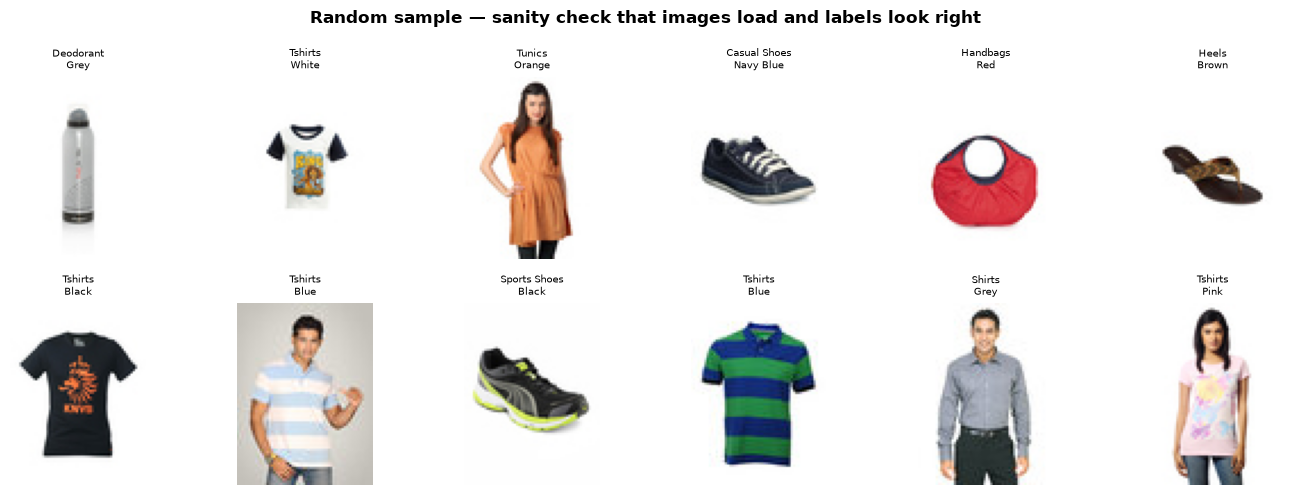

In [9]:
sample = df.sample(12, random_state=RANDOM_STATE)
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax, (_, r) in zip(axes.flat, sample.iterrows()):
    ax.imshow(Image.open(IMAGES_TRAIN_DIR / f"{r['id']}.jpg"))
    ax.axis("off")
    ax.set_title(f"{r['articleType']}\n{r['baseColour']}", fontsize=7)
fig.suptitle("Random sample — sanity check that images load and labels look right", fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Train / Validation Split

**Why not a plain random split:** a plain split doesn't check for duplicate images. We found 763 exact-duplicate image pairs earlier — a plain random split could put one copy in train and the other in validation. That's leakage: the model would basically get tested on a picture it already trained on.

**Why we split on `masterCategory`, not `articleType`:** `articleType` has a lot of rare classes. To split evenly on it, we'd first need to decide which classes count as "rare" — and if we work that out using the full dataset (train and validation together), we'd be using validation labels to help set up training. `masterCategory` avoids this problem. It only has a few categories (Apparel, Accessories, Footwear, and so on) and all of them have plenty of samples, so we can split on it directly with no extra decisions needed. The `articleType` rare-class decision is made later, after the split, using only the train data (see Section 6.3).

**Trade-off:** splitting on `masterCategory` keeps the broad categories balanced between train and validation, but it doesn't guarantee every single `articleType` class is split perfectly evenly. With about 29,000 training rows, this is a small price to pay for avoiding leakage completely.

**What we do:** one `StratifiedGroupKFold` split (about 75/25) — stratified on `masterCategory`, grouped on `dup_group` so duplicate images always stay on the same side. We only use one split, not full cross-validation: with ~29,000 rows this is enough data for a stable result, and doing 4-fold cross-validation would mean training every model four times over — time better spent improving the models themselves.

### 4.1 Doing the split

One more thing before splitting: `masterCategory` needs at least a handful of rows in every one of its categories for the split to work properly. A category with only one or two rows total can't be divided across train and validation at all. Since `masterCategory` isn't a prediction target for any task, dropping a tiny number of rows here doesn't touch anything the model is being trained to predict — it's a mechanical fix, not a modeling decision.

In [10]:
sgkf = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)  # 1 fold ~= 25%

# masterCategory needs at least n_splits rows per category for a clean split. A category
# with fewer rows than that can't be divided properly and ends up placed by chance --
# drop those rows first rather than let that happen silently.
master_counts = df['masterCategory'].value_counts()
too_rare_master = master_counts[master_counts < sgkf.get_n_splits()].index
if len(too_rare_master):
    n_dropped = df['masterCategory'].isin(too_rare_master).sum()
    print(f"Dropping {n_dropped} row(s) with a masterCategory that has fewer than "
          f"{sgkf.get_n_splits()} samples total: {list(too_rare_master)}")
    df = df[~df['masterCategory'].isin(too_rare_master)].reset_index(drop=True)

train_idx, val_idx = next(sgkf.split(df, df['masterCategory'], groups=df['dup_group']))
train_data = df.iloc[train_idx].reset_index(drop=True)
val_data = df.iloc[val_idx].reset_index(drop=True)

print(f"Train: {train_data.shape[0]}, Val: {val_data.shape[0]}")

# --- sanity checks ---
overlap = set(train_data['dup_group']) & set(val_data['dup_group'])
print(f"Duplicate-image groups appearing in BOTH splits: {len(overlap)} (should be 0)")

missing_master = set(df['masterCategory'].unique()) - set(train_data['masterCategory'].unique())
print(f"masterCategory classes missing from train: {missing_master if missing_master else 'none'}")

Dropping 1 row(s) with a masterCategory that has fewer than 4 samples total: ['Home']
Train: 28958, Val: 9653
Duplicate-image groups appearing in BOTH splits: 0 (should be 0)
masterCategory classes missing from train: none


## 5. Exploring the Train Data

This only looks at `train_data`, after the split — as the course asks, and so nothing below is influenced by the validation data.

### 5.1 Structure & overview

In [11]:
print(train_data.columns.tolist())
print(train_data.shape)
train_data.head()

['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'dup_group']
(28958, 11)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,dup_group
0,1164,Men,Apparel,Topwear,Tshirts,Blue,Winter,2015,Sports,Nike Men Blue T20 Indian Cricket Jersey,1164
1,1165,Men,Apparel,Topwear,Tshirts,Blue,Summer,2013,Sports,Nike Mean Team India Cricket Jersey,1165
2,1525,Unisex,Accessories,Bags,Backpacks,Navy Blue,Fall,2010,Casual,Puma Deck Navy Blue Backpack,1525
3,1526,Unisex,Accessories,Bags,Backpacks,Black,Fall,2010,Sports,Puma Big Cat Backpack Black,1526
4,1528,Men,Apparel,Topwear,Jackets,Black,Fall,2010,Sports,Puma Men Ferrari Black Fleece Jacket,1528


In [12]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 28958 entries, 0 to 28957
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id                  28958 non-null  str  
 1   gender              28958 non-null  str  
 2   masterCategory      28958 non-null  str  
 3   subCategory         28958 non-null  str  
 4   articleType         28958 non-null  str  
 5   baseColour          28948 non-null  str  
 6   season              28945 non-null  str  
 7   year                28958 non-null  int64
 8   usage               28902 non-null  str  
 9   productDisplayName  28954 non-null  str  
 10  dup_group           28958 non-null  str  
dtypes: int64(1), str(10)
memory usage: 2.4 MB


### 5.2 Missing values

In [13]:
missing = train_data.isnull().sum()
missing_pct = (missing / len(train_data)) * 100
missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct.round(2)}).sort_values('missing', ascending=False)
missing_df

,missing,pct
usage,56,0.19
season,13,0.04
baseColour,10,0.03
productDisplayName,4,0.01
masterCategory,0,0.00
id,0,0.00
gender,0,0.00
subCategory,0,0.00
articleType,0,0.00
year,0,0.00


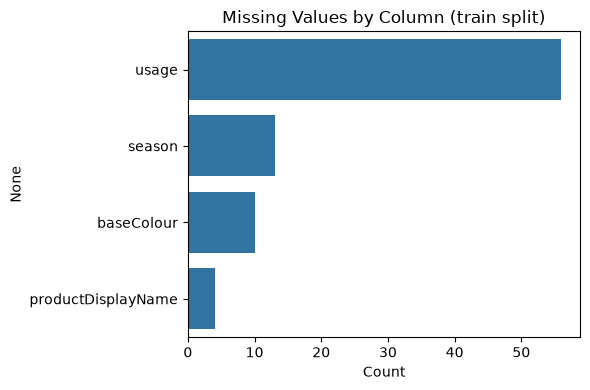

In [14]:
nonzero_missing = missing[missing > 0].sort_values(ascending=False)
if len(nonzero_missing):
    plt.figure(figsize=(6, 4))
    sns.barplot(x=nonzero_missing.values, y=nonzero_missing.index)
    plt.title('Missing Values by Column (train split)')
    plt.xlabel('Count')
    plt.tight_layout()
    plt.show()

### 5.3 Duplicate rows (metadata-level)

In [15]:
print(f"Duplicate rows: {train_data.duplicated().sum()}")
print(f"Duplicate ids: {train_data['id'].duplicated().sum()}")

Duplicate rows: 0
Duplicate ids: 0


### 5.4 Category distributions

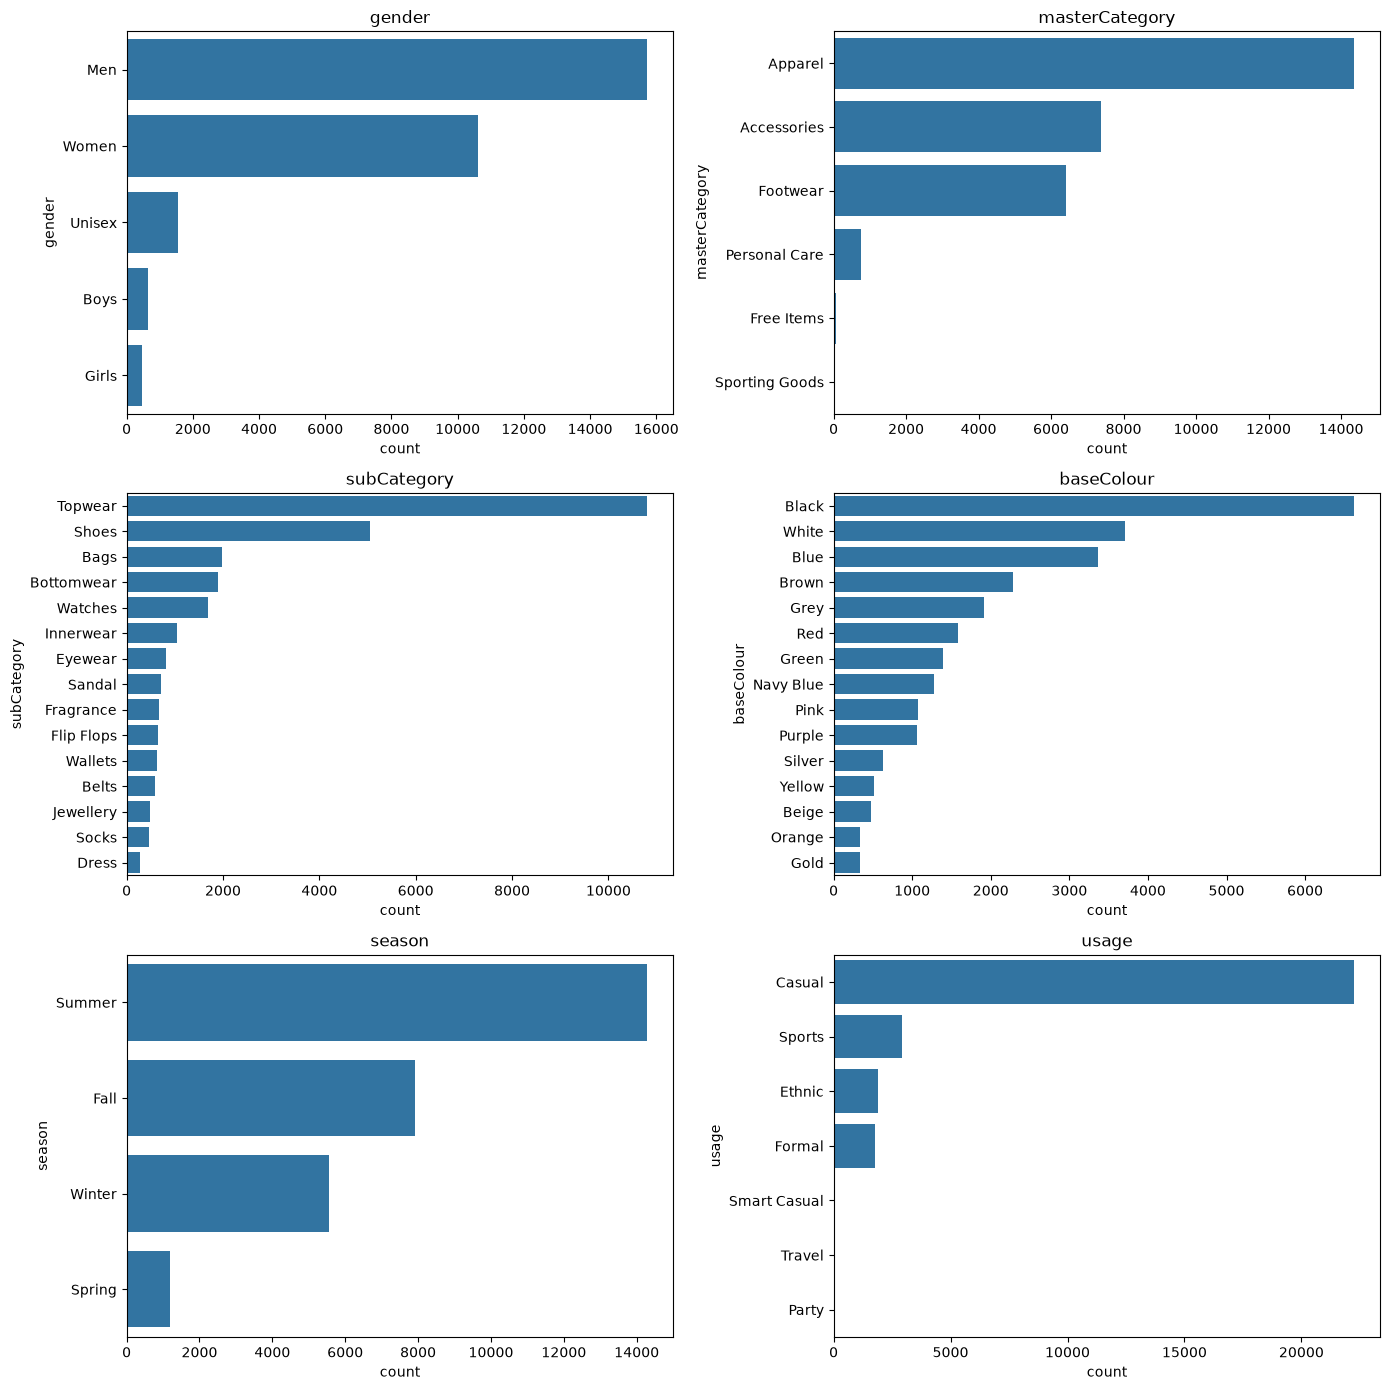

In [16]:
cat_cols = ['gender', 'masterCategory', 'subCategory', 'baseColour', 'season', 'usage']
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
for ax, col in zip(axes.flatten(), cat_cols):
    order = train_data[col].value_counts().index[:15]  # top 15 to keep it readable
    sns.countplot(data=train_data, y=col, order=order, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [17]:
print("Category distributions (summary):\n")
for col in cat_cols + ['articleType']:
    vc = train_data[col].value_counts()
    top_val, top_count = vc.index[0], vc.iloc[0]
    top_pct = top_count / len(train_data) * 100
    n_classes = vc.shape[0]
    least_val, least_count = vc.index[-1], vc.iloc[-1]
    print(f"- {col}: {n_classes} categories. "
          f"Most common is '{top_val}' ({top_count} items, {top_pct:.1f}%). "
          f"Least common is '{least_val}' ({least_count} items).")

Category distributions (summary):

- gender: 5 categories. Most common is 'Men' (15719 items, 54.3%). Least common is 'Girls' (469 items).
- masterCategory: 6 categories. Most common is 'Apparel' (14357 items, 49.6%). Least common is 'Sporting Goods' (18 items).
- subCategory: 39 categories. Most common is 'Topwear' (10800 items, 37.3%). Least common is 'Bath and Body' (1 items).
- baseColour: 46 categories. Most common is 'Black' (6622 items, 22.9%). Least common is 'Rose' (2 items).
- season: 4 categories. Most common is 'Summer' (14282 items, 49.3%). Least common is 'Spring' (1184 items).
- usage: 7 categories. Most common is 'Casual' (22247 items, 76.8%). Least common is 'Party' (11 items).
- articleType: 121 categories. Most common is 'Tshirts' (5122 items, 17.7%). Least common is 'Lounge Tshirts' (1 items).


### 5.5 The long tail in `articleType` (too many classes for a normal count plot)

In [18]:
vc = train_data['articleType'].value_counts()
print(f"Distinct articleType classes in train: {train_data['articleType'].nunique()}")
print(f"Classes with fewer than 10 samples: {(vc < 10).sum()}")
print(f"Classes with fewer than 5 samples:  {(vc < 5).sum()}")
vc.head(15)

Distinct articleType classes in train: 121
Classes with fewer than 10 samples: 39
Classes with fewer than 5 samples:  21


articleType
Tshirts         5122
Shirts          2306
Casual Shoes    2014
Watches         1679
Sports Shoes    1464
Tops            1197
Kurtas          1171
Handbags        1076
Sunglasses       813
Heels            775
Sandals          664
Flip Flops       651
Wallets          627
Belts            598
Backpacks        524
Name: count, dtype: int64

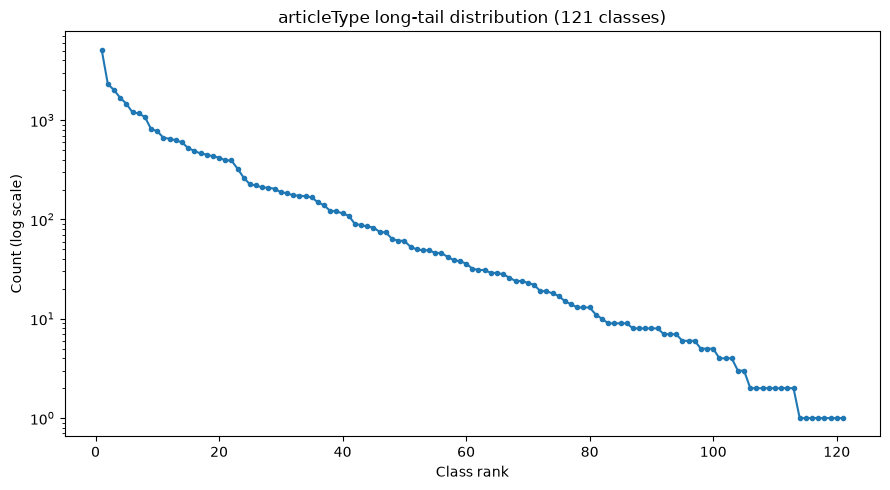

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(vc) + 1), vc.values, marker='o', markersize=3)
ax.set_yscale('log')
ax.set_xlabel('Class rank')
ax.set_ylabel('Count (log scale)')
ax.set_title(f'articleType long-tail distribution ({len(vc)} classes)')
plt.tight_layout()
plt.show()

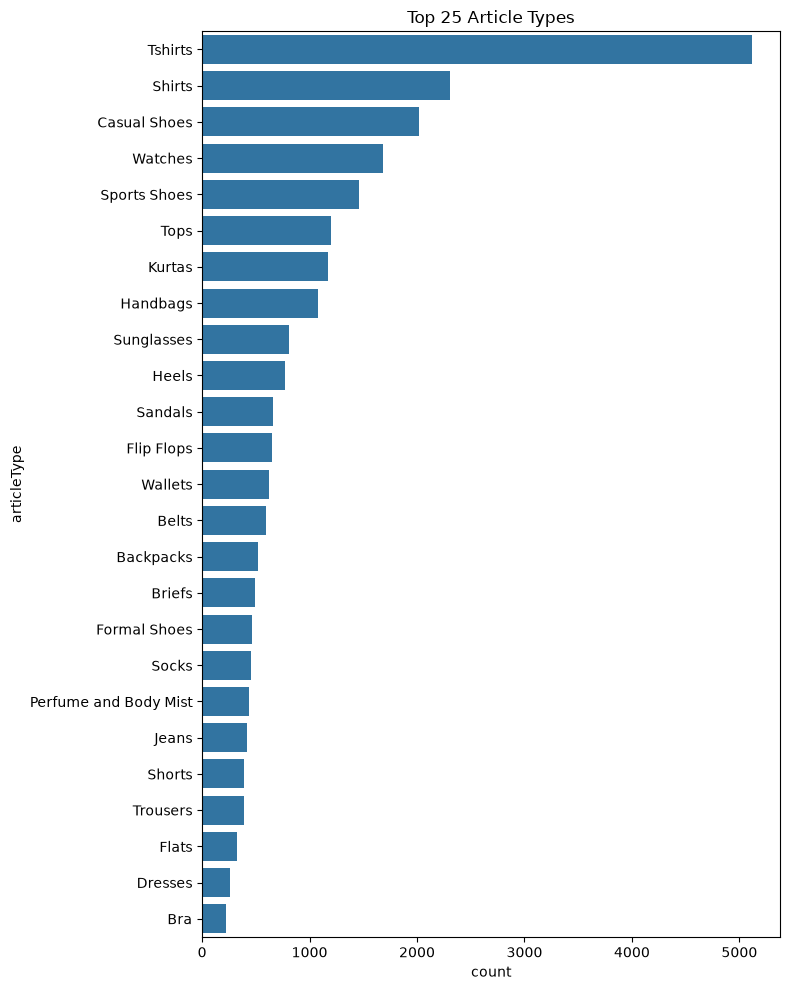

In [20]:
N = 25
plt.figure(figsize=(8, 10))
top_article = train_data['articleType'].value_counts().index[:N]
sns.countplot(data=train_data, y='articleType', order=top_article)
plt.title(f'Top {N} Article Types')
plt.tight_layout()
plt.show()

### 5.6 Year distribution & outliers

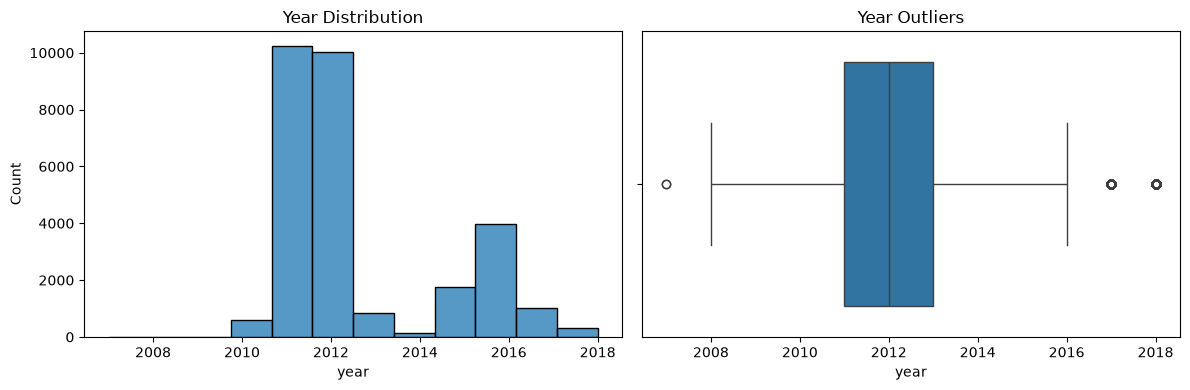

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_data['year'], bins=train_data['year'].nunique(), ax=axes[0])
axes[0].set_title('Year Distribution')
sns.boxplot(x=train_data['year'], ax=axes[1])
axes[1].set_title('Year Outliers')
plt.tight_layout()
plt.show()

In [22]:
year_counts = train_data['year'].value_counts().sort_index()

q1 = train_data['year'].quantile(0.25)
q3 = train_data['year'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_years = train_data[(train_data['year'] < lower_bound) | (train_data['year'] > upper_bound)]['year']
outlier_summary = outlier_years.value_counts().sort_index()

print(f"Data spans {train_data['year'].min():.0f} to {train_data['year'].max():.0f}.")
print(f"Most items are from {year_counts.idxmax():.0f} ({year_counts.max()} items).")
print(f"Outlier years (IQR rule): {outlier_summary.to_dict()}")

Data spans 2007 to 2018.
Most items are from 2011 (10241 items).
Outlier years (IQR rule): {2007: 2, 2017: 1003, 2018: 303}


### 5.7 Cramér's V — how strongly the feature columns are related

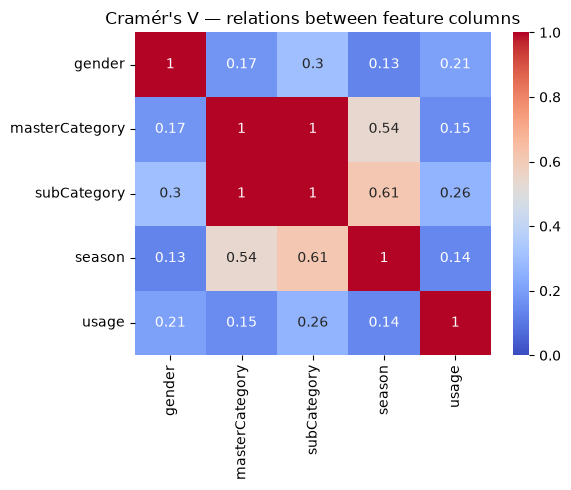

In [23]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

feature_cols = ['gender', 'masterCategory', 'subCategory', 'season', 'usage']
corr_matrix = pd.DataFrame(index=feature_cols, columns=feature_cols, dtype=float)
for c1, c2 in combinations(feature_cols, 2):
    v = cramers_v(train_data[c1], train_data[c2])
    corr_matrix.loc[c1, c2] = v
    corr_matrix.loc[c2, c1] = v
for c in feature_cols:
    corr_matrix.loc[c, c] = 1.0

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix.astype(float), annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Cramér's V — relations between feature columns")
plt.tight_layout()
plt.show()

### 5.8 Target distributions & relationships between targets

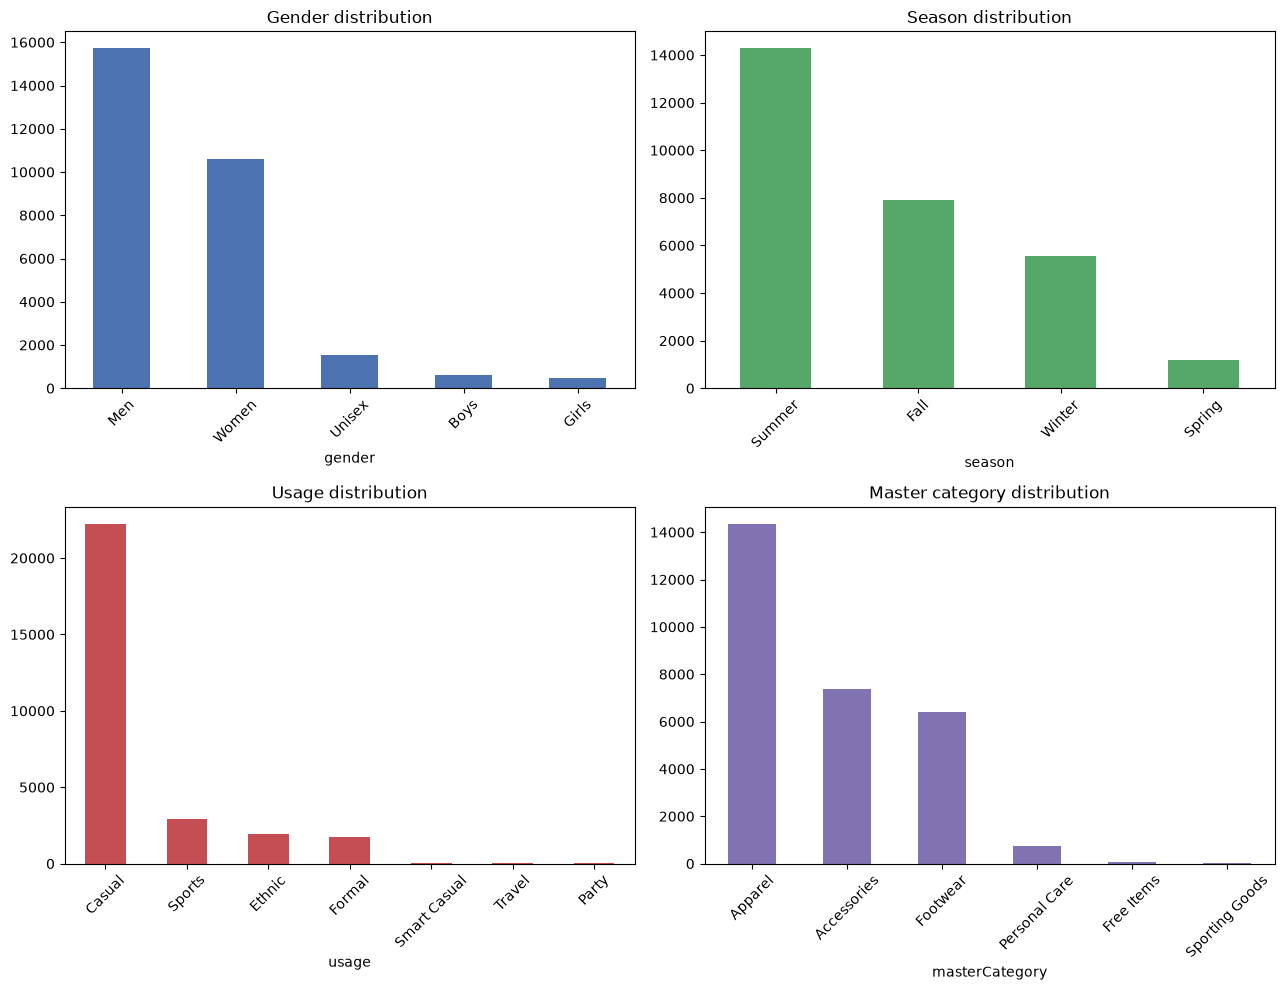

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

train_data['gender'].value_counts().plot(kind='bar', ax=axes[0, 0], color='#4C72B0')
axes[0, 0].set_title('Gender distribution')
axes[0, 0].tick_params(axis='x', rotation=45)

train_data['season'].value_counts().plot(kind='bar', ax=axes[0, 1], color='#55A868')
axes[0, 1].set_title('Season distribution')
axes[0, 1].tick_params(axis='x', rotation=45)

train_data['usage'].value_counts().plot(kind='bar', ax=axes[1, 0], color='#C44E52')
axes[1, 0].set_title('Usage distribution')
axes[1, 0].tick_params(axis='x', rotation=45)

train_data['masterCategory'].value_counts().plot(kind='bar', ax=axes[1, 1], color='#8172B2')
axes[1, 1].set_title('Master category distribution')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

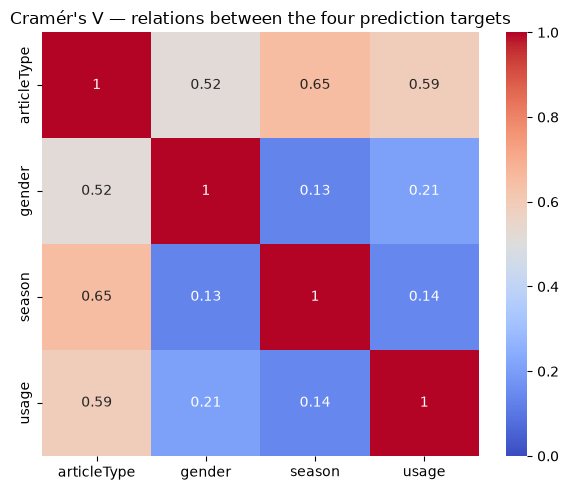

In [25]:
targets = ['articleType', 'gender', 'season', 'usage']

target_corr = pd.DataFrame(index=targets, columns=targets, dtype=float)
for c1, c2 in combinations(targets, 2):
    v = cramers_v(train_data[c1], train_data[c2])
    target_corr.loc[c1, c2] = v
    target_corr.loc[c2, c1] = v
for c in targets:
    target_corr.loc[c, c] = 1.0

plt.figure(figsize=(6, 5))
sns.heatmap(target_corr.astype(float), annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Cramér's V — relations between the four prediction targets")
plt.tight_layout()
plt.show()

Strongest target relationship: articleType vs season (Cramér's V = 0.65)


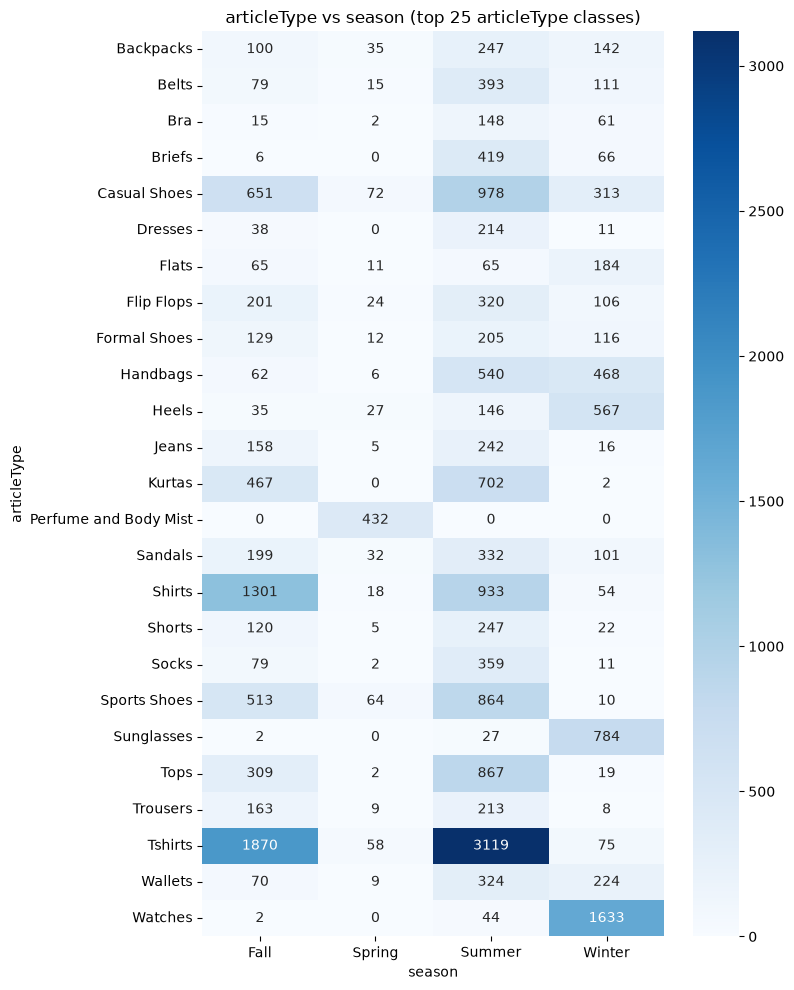

In [26]:
# The strongest target-target relationship, viewed as a crosstab heatmap
strongest_pair = target_corr.where(~np.eye(len(targets), dtype=bool)).stack().idxmax()
c1, c2 = strongest_pair
print(f"Strongest target relationship: {c1} vs {c2} (Cramér's V = {target_corr.loc[c1, c2]:.2f})")

plt.figure(figsize=(8, 10))
ct = pd.crosstab(train_data[c1], train_data[c2])
top_types = train_data[c1].value_counts().index[:25]
sns.heatmap(ct.loc[ct.index.intersection(top_types)], annot=True, fmt='d', cmap='Blues')
plt.title(f'{c1} vs {c2} (top 25 {c1} classes)')
plt.tight_layout()
plt.show()

### 5.9 How imbalanced are the classes

In [27]:
def imbalance_summary(series, name):
    vc = series.dropna().value_counts()
    ratio = vc.max() / vc.min()
    return {
        'target': name,
        'n_classes': len(vc),
        'majority_class': vc.idxmax(),
        'majority_count': int(vc.max()),
        'minority_class': vc.idxmin(),
        'minority_count': int(vc.min()),
        'imbalance_ratio': round(ratio, 1),
    }

imbalance_table = pd.DataFrame([
    imbalance_summary(train_data['gender'], 'gender'),
    imbalance_summary(train_data['season'], 'season'),
    imbalance_summary(train_data['usage'], 'usage'),
    imbalance_summary(train_data['articleType'], 'articleType'),
])
imbalance_table

,target,n_classes,majority_class,majority_count,minority_class,minority_count,imbalance_ratio
0,gender,5,Men,15719,Girls,469,33.5
1,season,4,Summer,14282,Spring,1184,12.1
2,usage,7,Casual,22247,Party,11,2022.5
3,articleType,121,Tshirts,5122,Shoe Laces,1,5122.0


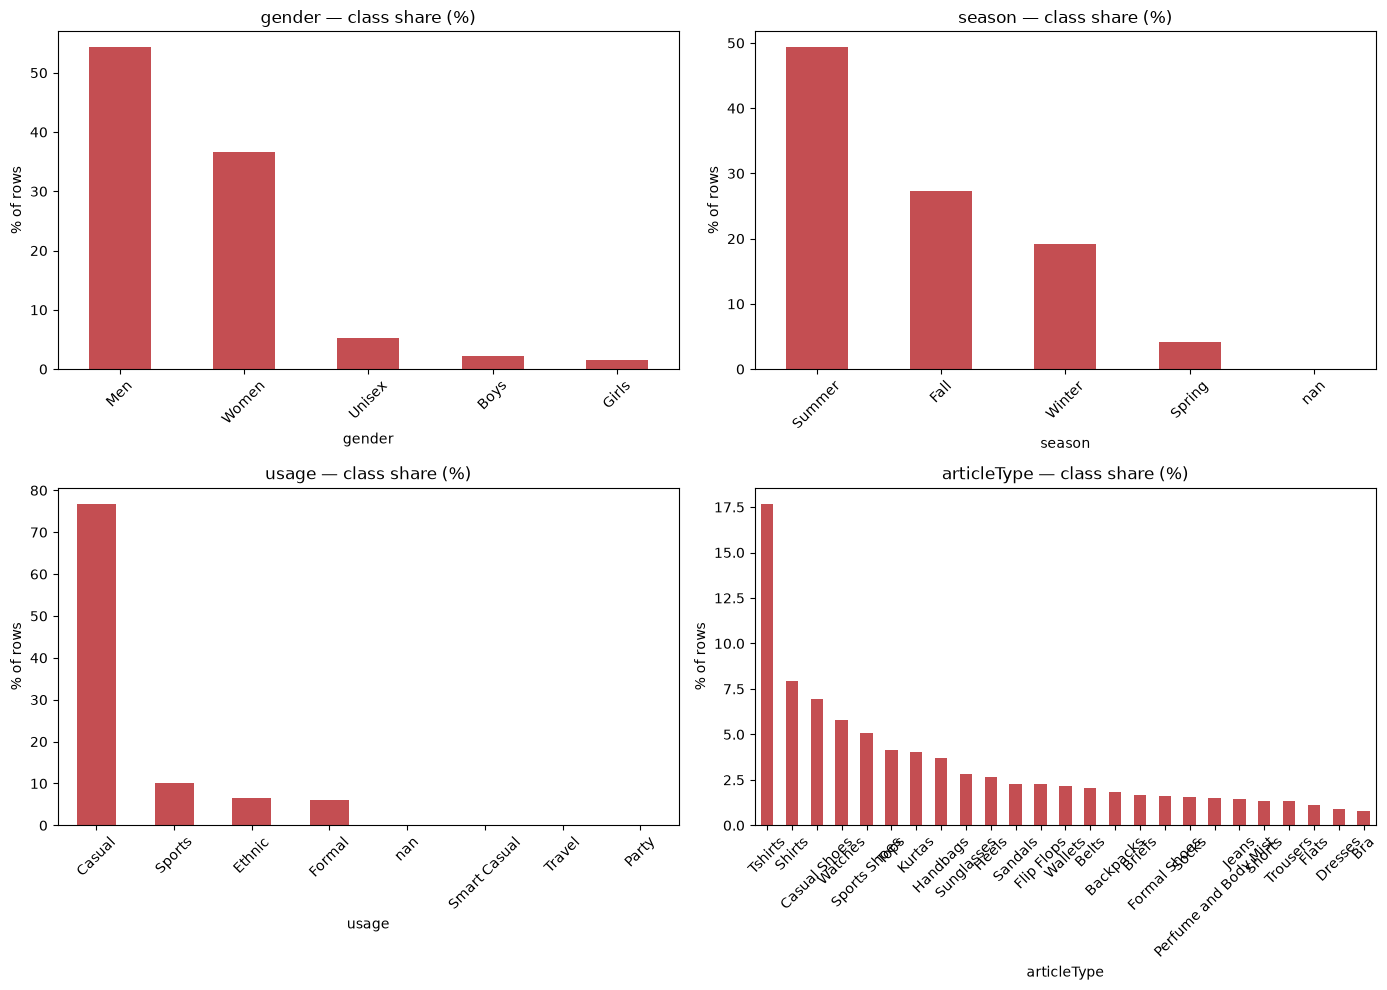

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), ['gender', 'season', 'usage', 'articleType']):
    shares = train_data[col].value_counts(normalize=True, dropna=False) * 100
    if col == 'articleType':
        shares = shares.head(25)
    shares.plot(kind='bar', ax=ax, color='#C44E52')
    ax.set_ylabel('% of rows')
    ax.set_title(f'{col} — class share (%)')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 5.10 Checking the images: size, color mode, file size (train data only)

In [29]:
def profile_images(ids, folder):
    rows = []
    for img_id in ids:
        p = folder / f"{img_id}.jpg"
        try:
            with Image.open(p) as im:      # reads header only, fast
                w, h, mode = im.size[0], im.size[1], im.mode
        except Exception:
            w = h = None
            mode = "ERR"
        rows.append({"id": img_id, "w": w, "h": h, "mode": mode,
                     "kb": round(p.stat().st_size / 1024, 2)})
    return pd.DataFrame(rows)

imgs_train = profile_images(train_data['id'], IMAGES_TRAIN_DIR)
print("Most common dimensions (train):")
print(imgs_train.groupby(['w', 'h']).size().sort_values(ascending=False).head())
print("\nColour mode counts (train):", imgs_train['mode'].value_counts().to_dict())

Most common dimensions (train):
w   h 
60  80    28945
53  80        5
60  60        4
    77        2
    76        1
dtype: int64

Colour mode counts (train): {'RGB': 28709, 'L': 249}


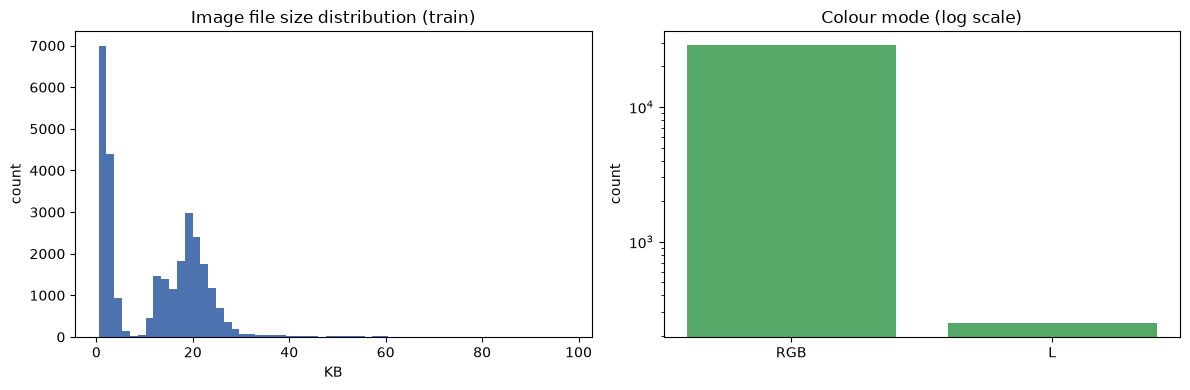

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(imgs_train["kb"], bins=60, color="#4C72B0")
ax[0].set(title="Image file size distribution (train)", xlabel="KB", ylabel="count")

mode_counts = imgs_train["mode"].value_counts()
ax[1].bar(mode_counts.index.astype(str), mode_counts.values, color="#55A868")
ax[1].set_yscale("log")
ax[1].set(title="Colour mode (log scale)", ylabel="count")
plt.tight_layout()
plt.show()

**What we found:**
- About 38,600 training images, almost all a consistent 60x80 pixels, with a few size outliers.
- A small number of images are grayscale, not color — these need converting to RGB before going into a CNN (done in Section 6.7).
- File sizes are mostly small (under 25 KB), with no signs of corrupted files.
- `articleType` has a long tail — many classes with fewer than 10 samples. This gets fixed in Section 6.3.
- `usage` is mostly `Casual`, and `gender` is mostly `Men`/`Women` — both are handled by the imbalance fix in Section 6.6.
- None of the feature and target columns are strongly linked enough to drop any of them.

## 6. Processing the Data

This section builds the four datasets (`articleType`, `season`, `gender`, `usage`) that Tasks 1-3 will train on, and explains the reasoning behind each decision.

### 6.1 Basic cleaning

This same cleaning function runs on both `train_data` and `val_data`. It doesn't learn anything from the data (no fitting), so using the same function on both is safe — no leakage risk.

In [31]:
def clean_dataframe(data):
    """Whitespace-strip categorical/text columns, coerce year to numeric,
    and fill non-target missing values with a placeholder. Fit-free — safe
    to reuse on train, val, or a future test split."""
    data = data.copy()

    # Note: 'articleType_grouped' isn't in this list -- it doesn't exist yet at this point
    # in the pipeline (created in Section 6.3, after cleaning), and it derives from
    # already-cleaned 'articleType'/'subCategory' values, so it needs no separate stripping.
    cat_cols = ['gender', 'masterCategory', 'subCategory', 'articleType',
                'baseColour', 'season', 'usage', 'productDisplayName']
    for c in cat_cols:
        if c in data.columns:
            data[c] = data[c].astype('string').str.strip()

    if 'year' in data.columns:
        data['year'] = pd.to_numeric(data['year'], errors='coerce')

    # baseColour / productDisplayName aren't prediction targets, so missing values
    # here don't block any task — fill rather than drop.
    for c in ['baseColour', 'productDisplayName']:
        if c in data.columns:
            data[c] = data[c].fillna('Unknown')

    return data

train_data = clean_dataframe(train_data)
val_data = clean_dataframe(val_data)

print("Missing values after cleaning (train):")
print(train_data.isnull().sum())
print("\nMissing values after cleaning (val):")
print(val_data.isnull().sum())

Missing values after cleaning (train):
id                     0
gender                 0
masterCategory         0
subCategory            0
articleType            0
baseColour             0
season                13
year                   0
usage                 56
productDisplayName     0
dup_group              0
dtype: int64

Missing values after cleaning (val):
id                     0
gender                 0
masterCategory         0
subCategory            0
articleType            0
baseColour             0
season                 7
year                   0
usage                 16
productDisplayName     0
dup_group              0
dtype: int64


### 6.2 What to do about missing values, per task

`season` and `usage` are prediction targets, so we can't fill in a missing value without just guessing a label. Rows missing those values get dropped, but only for that one task — not from the shared `train_data`/`val_data`. `articleType` and `gender` have no missing values. This is handled in Section 6.4, where we build a separate dataset for each task.

### 6.3 Handling rare classes, per task

**`articleType`** — this is worked out using train data only, so validation rows are never looked at. Classes with too few samples get relabelled to their own `subCategory` instead of a single "Other" bucket. For example, a rare class like "Rain Trousers" becomes "Bottomwear". This keeps more useful information than dumping everything into one catch-all label. One trade-off worth mentioning in the report: this mixes two levels of detail in one column — some rows keep a specific label like "T-shirts", others become a broader one like "Bottomwear" after being redistributed. A validation row whose `articleType` never appears in train at all (so it can't be judged "rare" from train counts, since it has zero train count, not just a low one) gets caught and dropped automatically later, at the label-encoding step in Section 6.5 — not handled here, so this step never has to look at validation data.

In [32]:
vc_article = train_data['articleType'].value_counts()
print(f"Total articleType classes (train): {len(vc_article)}")
print(f"Classes with fewer than 10 samples: {(vc_article < 10).sum()}")
print(f"Classes with fewer than 5 samples:  {(vc_article < 5).sum()}\n")

for thresh in [5, 10, 15, 20, 30, 50]:
    kept_classes = (vc_article >= thresh).sum()
    kept_rows = vc_article[vc_article >= thresh].sum()
    print(f"threshold={thresh:>3}: classes kept={kept_classes:>3}/{len(vc_article)}, "
          f"rows kept={kept_rows:>6} ({kept_rows/len(train_data)*100:.1f}% of train)")

Total articleType classes (train): 121
Classes with fewer than 10 samples: 39
Classes with fewer than 5 samples:  21

threshold=  5: classes kept=100/121, rows kept= 28916 (99.9% of train)
threshold= 10: classes kept= 82/121, rows kept= 28786 (99.4% of train)
threshold= 15: classes kept= 76/121, rows kept= 28712 (99.2% of train)
threshold= 20: classes kept= 71/121, rows kept= 28624 (98.8% of train)
threshold= 30: classes kept= 63/121, rows kept= 28419 (98.1% of train)
threshold= 50: classes kept= 52/121, rows kept= 27980 (96.6% of train)


In [33]:
ARTICLE_TYPE_MIN_COUNT = 20  # keeps most classes while dropping the near-unlearnable long tail

rare_article_types = set(vc_article[vc_article < ARTICLE_TYPE_MIN_COUNT].index)

def apply_article_type_grouping(data, rare_set):
    """Redistributes rare articleType rows into their own subCategory, rather than a
    single 'Other' bucket. `rare_set` is fixed from train-only counts and applied as-is
    to both splits -- never recomputed from val."""
    data = data.copy()
    rare_mask = data['articleType'].isin(rare_set)
    data['articleType_grouped'] = data['articleType']
    data.loc[rare_mask, 'articleType_grouped'] = data.loc[rare_mask, 'subCategory']
    return data

train_data = apply_article_type_grouping(train_data, rare_article_types)
val_data = apply_article_type_grouping(val_data, rare_article_types)

print(f"Rare articleType classes folded into subCategory: {len(rare_article_types)}")
print("Classes after grouping (train):", train_data['articleType_grouped'].nunique())
print("\nRare rows redistributed into (train):")
print(train_data.loc[train_data['articleType'].isin(rare_article_types), 'articleType_grouped'].value_counts())

Rare articleType classes folded into subCategory: 50
Classes after grouping (train): 92

Rare rows redistributed into (train):
articleType_grouped
Bottomwear                  80
Topwear                     31
Lips                        28
Bags                        26
Shoe Accessories            19
Makeup                      18
Sports Equipment            15
Gloves                      15
Innerwear                   15
Nails                       14
Accessories                 13
Apparel Set                 10
Dress                       10
Headwear                     8
Socks                        8
Eyes                         6
Umbrellas                    4
Loungewear and Nightwear     4
Water Bottle                 3
Wristbands                   3
Sports Accessories           2
Cufflinks                    1
Bath and Body                1
Name: count, dtype: Int64


In [34]:
# Verify the redistribution actually fixed the imbalance -- if a subCategory a rare
# articleType got folded into is itself still small, the long tail has moved, not gone.
post_counts = train_data['articleType_grouped'].value_counts()
still_rare = post_counts[post_counts < ARTICLE_TYPE_MIN_COUNT]
print(f"articleType_grouped classes still below {ARTICLE_TYPE_MIN_COUNT} samples after redistribution: {len(still_rare)}")
if len(still_rare):
    print(still_rare)

articleType_grouped classes still below 20 samples after redistribution: 17
articleType_grouped
Shoe Accessories            19
Makeup                      18
Sports Equipment            15
Gloves                      15
Innerwear                   15
Nails                       14
Accessories                 13
Apparel Set                 10
Dress                       10
Headwear                     8
Eyes                         6
Umbrellas                    4
Loungewear and Nightwear     4
Water Bottle                 3
Wristbands                   3
Sports Accessories           2
Bath and Body                1
Name: count, dtype: Int64


**`usage`** doesn't have a parent column to redistribute into, so rare classes here still go into "Other". One class (`Home`) has almost just a single sample in the whole dataset — too rare to even split between train and validation. Same train-only approach as `articleType`, applied here:

In [35]:
USAGE_MIN_COUNT = 100

vc_usage = train_data['usage'].value_counts()
for thresh in [10, 25, 50, 100, 150]:
    kept_classes = (vc_usage >= thresh).sum()
    kept_rows = vc_usage[vc_usage >= thresh].sum()
    print(f"threshold={thresh:>3}: classes kept={kept_classes}/{len(vc_usage)}, "
          f"rows kept={kept_rows} ({kept_rows/train_data['usage'].notna().sum()*100:.1f}% of usage rows)")

threshold= 10: classes kept=7/7, rows kept=28902 (100.0% of usage rows)
threshold= 25: classes kept=5/7, rows kept=28879 (99.9% of usage rows)
threshold= 50: classes kept=4/7, rows kept=28836 (99.8% of usage rows)
threshold=100: classes kept=4/7, rows kept=28836 (99.8% of usage rows)
threshold=150: classes kept=4/7, rows kept=28836 (99.8% of usage rows)


In [36]:
rare_usage = vc_usage[vc_usage < USAGE_MIN_COUNT].index

for d in (train_data, val_data):
    d['usage_grouped'] = d['usage'].where(~d['usage'].isin(rare_usage), 'Other')

print("usage classes after grouping (train):", train_data['usage_grouped'].nunique())
print(train_data['usage_grouped'].value_counts())

usage classes after grouping (train): 5
usage_grouped
Casual    22247
Sports     2923
Ethnic     1916
Formal     1750
Other        66
Name: count, dtype: Int64


**`gender`** and **`season`** don't need any merging. `gender` has 5 classes and `season` has 4. Both are imbalanced (see Section 5.9), but every class still has enough samples to split, encode, and learn from without needing to combine categories.

### 6.4 One dataset per task

In [37]:
# Column actually used as the prediction target for each task
target_columns = {
    'articleType': 'articleType_grouped',
    'season': 'season',
    'gender': 'gender',
    'usage': 'usage_grouped',
}

def usable_subset(data, target_col):
    return data[data[target_col].notna()].reset_index(drop=True)

train_usable = {t: usable_subset(train_data, col) for t, col in target_columns.items()}
val_usable = {t: usable_subset(val_data, col) for t, col in target_columns.items()}

for t in target_columns:
    print(f"{t}: train usable={len(train_usable[t])}, val usable={len(val_usable[t])}")

articleType: train usable=28958, val usable=9653
season: train usable=28945, val usable=9646
gender: train usable=28958, val usable=9653
usage: train usable=28902, val usable=9637


### 6.4.1 A separate split for Task 2 (`season`)

`season` isn't correlated with `masterCategory` the way `articleType` is — a "Summer" item can be a shirt, a shoe, or a bag, cutting across every `masterCategory` roughly evenly. So the shared `masterCategory`-stratified split above gives no real guarantee that `season` classes are proportionally represented between train and validation for Task 2. Here we redo the split for Task 2 only, stratified directly on `season`, keeping the same duplicate-image grouping constraint so leakage is still prevented. This overwrites `train_usable['season']`/`val_usable['season']` before anything downstream uses them, so Tasks 1, 3, and 4 are unaffected.

In [38]:
def class_balance(train_df, val_df, col):
    """Train% vs val% per class, sorted by the biggest gap -- used to sanity-check
    how representative a split is for a given target column."""
    comp = pd.DataFrame({
        'train_%': train_df[col].value_counts(normalize=True).sort_index(),
        'val_%':   val_df[col].value_counts(normalize=True).sort_index(),
    }).round(4)
    comp['abs_diff'] = (comp['train_%'] - comp['val_%']).abs()
    return comp.sort_values('abs_diff', ascending=False)

print('Season balance -- shared masterCategory-stratified split (before):')
print(class_balance(train_usable['season'], val_usable['season'], 'season'))

sgkf_season = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

# Only rows with a known season can be stratified on it -- same 'drop, don't impute'
# decision as for the target itself elsewhere in this notebook.
df_season_pool = df[df['season'].notna()].reset_index(drop=True)

season_counts = df_season_pool['season'].value_counts()
too_rare_season = season_counts[season_counts < sgkf_season.get_n_splits()].index
if len(too_rare_season):
    n_dropped = df_season_pool['season'].isin(too_rare_season).sum()
    print(f"Dropping {n_dropped} row(s) with a season that has fewer than "
          f"{sgkf_season.get_n_splits()} samples total: {list(too_rare_season)}")
    df_season_pool = df_season_pool[~df_season_pool['season'].isin(too_rare_season)].reset_index(drop=True)

season_train_idx, season_val_idx = next(
    sgkf_season.split(df_season_pool, df_season_pool['season'], groups=df_season_pool['dup_group'])
)
season_train_data = df_season_pool.iloc[season_train_idx].reset_index(drop=True)
season_val_data = df_season_pool.iloc[season_val_idx].reset_index(drop=True)

overlap = set(season_train_data['dup_group']) & set(season_val_data['dup_group'])
print(f"\nTask 2 split -- duplicate-image groups appearing in BOTH sides: {len(overlap)} (should be 0)")
print(f"Task 2 split -- train: {len(season_train_data)}, val: {len(season_val_data)}")

# Overwrite train_usable/val_usable['season'] so every downstream cell (label encoding,
# samplers, datasets, config export, leakage checks) automatically uses this split for
# Task 2 -- no other code changes needed anywhere else in the notebook.
train_usable['season'] = usable_subset(season_train_data, 'season')
val_usable['season'] = usable_subset(season_val_data, 'season')

print('\nSeason balance -- season-stratified split (after):')
print(class_balance(train_usable['season'], val_usable['season'], 'season'))

print(f"\nseason: train usable={len(train_usable['season'])}, val usable={len(val_usable['season'])}")


Season balance -- shared masterCategory-stratified split (before):
        train_%   val_%  abs_diff
season                           
Summer   0.4934  0.5031    0.0097
Fall     0.2737  0.2685    0.0052
Winter    0.192  0.1888    0.0032
Spring   0.0409  0.0396    0.0013

Task 2 split -- duplicate-image groups appearing in BOTH sides: 0 (should be 0)
Task 2 split -- train: 28943, val: 9648

Season balance -- season-stratified split (after):
        train_%   val_%  abs_diff
season                           
Winter   0.1912  0.1911    0.0001
Summer   0.4958  0.4959    0.0001
Spring   0.0406  0.0406    0.0000
Fall     0.2724  0.2724    0.0000

season: train usable=28943, val usable=9648


### 6.5 Turning labels into numbers

Each task gets its own label encoder, fit on train data only — since each task drops different rows, one shared encoder wouldn't make sense across all of them. If validation ever has a label the encoder never saw in train (shouldn't happen after our split, but we check anyway), that row gets flagged and dropped instead of silently causing an error.

In [39]:
encoders = {}
label_maps = {}

for t, col in target_columns.items():
    le = LabelEncoder()
    le.fit(train_usable[t][col])
    encoders[t] = le
    label_maps[t] = {i: c for i, c in enumerate(le.classes_)}

    train_usable[t][col + '_enc'] = le.transform(train_usable[t][col])

    val_known = val_usable[t][val_usable[t][col].isin(le.classes_)]
    dropped = len(val_usable[t]) - len(val_known)
    if dropped:
        print(f"WARNING: dropped {dropped} val rows for '{t}' — label(s) not seen in train")
    val_usable[t] = val_known.reset_index(drop=True)
    val_usable[t][col + '_enc'] = le.transform(val_usable[t][col])

    print(f"{t}: {len(le.classes_)} classes" + (f" -> {label_maps[t]}" if len(le.classes_) <= 6 else ""))

articleType: 92 classes
season: 4 classes -> {0: 'Fall', 1: 'Spring', 2: 'Summer', 3: 'Winter'}
gender: 5 classes -> {0: 'Boys', 1: 'Girls', 2: 'Men', 3: 'Unisex', 4: 'Women'}
usage: 5 classes -> {0: 'Casual', 1: 'Ethnic', 2: 'Formal', 3: 'Other', 4: 'Sports'}


### 6.6 Fixing class imbalance

**Options we thought about:** giving rare classes more weight in the loss function, oversampling them, or augmenting their images. Using all three together tends to over-correct, so we picked one consistent approach for all four tasks instead of tuning something different for each.

**What we're using: `WeightedRandomSampler`**, together with the augmentation from Section 6.8. This is built from training rows only — validation is never resampled, so it still reflects the real, imbalanced distribution.

- **Why not also weight the loss function:** once the sampler is already balancing each batch, adding loss weighting on top would double-punish the common classes — risky for `articleType`, where some of those weights would be very small. We calculate class weights below just for reference, but don't actually use them in training.
- **Why the sampler needs augmentation:** the sampler picks the same rare-class images again and again (with replacement). Without variation, the model could just memorize those exact images instead of learning to generalize. Augmentation (flip, rotate, adjust color — Section 6.8) makes each repeat draw look a bit different.
- **Why not SMOTE:** SMOTE blends pixels between different photos to make synthetic examples, which for product photos just produces unrealistic-looking images. Augmentation does the same job in a way that makes sense for images.
- **One more thing to track:** always look at macro-F1 next to accuracy in the modelling notebooks. Accuracy alone can be misleading here — a `usage` model that only ever predicts "Casual" would still score around 77% accuracy while being useless.

In [40]:
# Reference-only class weights (not used in the training loss)
class_weights = {}
for t, col in target_columns.items():
    data = train_usable[t]
    vc = data[col].value_counts().sort_index()
    n_classes, n_samples = len(vc), len(data)
    weights = n_samples / (n_classes * vc)
    weights = weights / weights.mean()
    ordered = [weights[c] for c in encoders[t].classes_]
    class_weights[t] = np.array(ordered)
    print(f"{t}: weight range {class_weights[t].min():.2f}-{class_weights[t].max():.2f}")

articleType: weight range 0.00-19.84
season: weight range 0.23-2.77
gender: weight range 0.07-2.36
usage: weight range 0.01-4.55


In [41]:
def get_weighted_sampler(data, target_col):
    """WeightedRandomSampler that oversamples minority classes within `data`.
    Call on the training subset only."""
    class_counts = data[target_col].value_counts()
    inv_freq = {cls: 1.0 / count for cls, count in class_counts.items()}
    sample_weights = torch.tensor(data[target_col].map(inv_freq).values, dtype=torch.float32)
    return WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

samplers = {}
for t, col in target_columns.items():
    samplers[t] = get_weighted_sampler(train_usable[t], col)
    print(f"{t}: sampler built on {len(train_usable[t])} training rows")

articleType: sampler built on 28958 training rows
season: sampler built on 28943 training rows
gender: sampler built on 28958 training rows
usage: sampler built on 28902 training rows


### 6.7 Image size and normalization

**Size:** we keep the images at their natural 60x80 size (width x height) instead of forcing them into a square. Squaring them would stretch every image out of shape for no real benefit, since 60x80 is already the size almost all images already are (see Section 5.10).

**Normalization:** we calculate the average and spread of pixel values (per color channel) from a sample of train images, instead of just dividing by 255. This is standard practice for training CNNs — it centers the pixel values around zero, which a plain 0-to-1 scale doesn't do.

In [42]:
IMG_WIDTH, IMG_HEIGHT = 60, 80

sample_ids = train_data['id'].sample(min(3000, len(train_data)), random_state=RANDOM_STATE)

pixel_sum = np.zeros(3)
pixel_sq_sum = np.zeros(3)
n_pixels = 0

for img_id in sample_ids:
    img = Image.open(IMAGES_TRAIN_DIR / f"{img_id}.jpg").convert("RGB")
    arr = np.asarray(img, dtype=np.float64) / 255.0
    pixel_sum += arr.sum(axis=(0, 1))
    pixel_sq_sum += (arr ** 2).sum(axis=(0, 1))
    n_pixels += arr.shape[0] * arr.shape[1]

mean = pixel_sum / n_pixels
std = np.sqrt(pixel_sq_sum / n_pixels - mean ** 2)

print(f"Computed mean (RGB): {mean.round(4)}")
print(f"Computed std (RGB):  {std.round(4)}")

Computed mean (RGB): [0.8508 0.8336 0.8284]
Computed std (RGB):  [0.2709 0.2829 0.2858]


### 6.8 Transform pipelines

In [43]:
# Base/eval pipeline — used for validation, test, and as the foundation of the
# training pipeline. Never augmented, so it stays a faithful evaluation signal.
base_transform = T.Compose([
    T.Lambda(lambda img: img.convert("RGB")),   # handles the grayscale files found in Section 5.10
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])
eval_transform = base_transform

# Training pipeline — adds mild, conservative augmentation. Kept conservative because
# these are catalog product photos, not natural scenes: a vertical flip or a large
# rotation would produce an unrealistic example (e.g. an upside-down shoe).
train_transform = T.Compose([
    T.Lambda(lambda img: img.convert("RGB")),
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])

print("Transforms ready: base_transform / eval_transform (no augmentation), train_transform (augmented)")

Transforms ready: base_transform / eval_transform (no augmentation), train_transform (augmented)


Augmentation isn't targeted at rare classes specifically — it just naturally works well with the sampler from Section 6.6. Since rare-class images get picked more often by the sampler, they also get augmented more often, which is exactly the extra variety they need.

### 6.9 Wrapping everything in a PyTorch Dataset

In [44]:
class FashionImageDataset(Dataset):
    """Wraps a per-task dataframe (from train_usable / val_usable) with its images
    and label encoder. Pass `train_transform` for training data, `eval_transform`
    for validation/test data."""

    def __init__(self, dataframe, images_dir, target_col_enc, transform):
        self.df = dataframe.reset_index(drop=True)
        self.images_dir = images_dir
        self.target_col_enc = target_col_enc
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(self.images_dir / f"{row['id']}.jpg") as im:
            img = self.transform(im)
        label = int(row[self.target_col_enc])
        return img, torch.tensor(label, dtype=torch.long)


# Example: build the four training datasets (validation datasets follow the same pattern
# with eval_transform and no sampler)
task_datasets = {
    t: FashionImageDataset(train_usable[t], IMAGES_TRAIN_DIR, col + '_enc', train_transform)
    for t, col in target_columns.items()
}
for t, ds in task_datasets.items():
    print(f"{t}: {len(ds)} training images")

articleType: 28958 training images
season: 28943 training images
gender: 28958 training images
usage: 28902 training images


### 6.10 Saving all our settings in one file

Every threshold, seed, and decision made in this notebook gets saved here in one place, so a teammate or a marker can see what was decided without having to re-run everything above.

In [45]:
config = {
    "random_state": RANDOM_STATE,
    "split": {
        "method": "single_stratified_group_holdout",
        "splitter": "StratifiedGroupKFold(n_splits=4), first split only",
        "validation_fraction": 0.25,
        "stratify_on": {
            "articleType": "masterCategory",  # deliberately not articleType itself -- see Section 4
            "gender": "masterCategory",
            "usage": "masterCategory",
            "season": "season",  # re-split for Task 2 only -- see Section 6.4.1
        },
        "group_on": "dup_group (exact-duplicate images)",
    },
    "image": {
        "width": IMG_WIDTH,
        "height": IMG_HEIGHT,
        "normalization_mean": mean.tolist(),
        "normalization_std": std.tolist(),
    },
    "rare_class_thresholds": {
        "articleType": ARTICLE_TYPE_MIN_COUNT,
        "usage": USAGE_MIN_COUNT,
    },
    "rare_class_handling": {
        "articleType": "redistributed into subCategory (train-only counts + val-only-class check)",
        "usage": "redistributed into 'Other' (no parent column to redistribute into)",
    },
    "class_counts": {t: int(len(encoders[t].classes_)) for t in target_columns},
    "imbalance_handling": "WeightedRandomSampler (train only) + augmentation; no loss-level class weighting",
    "missing_images_dropped": missing_images,
    "duplicate_image_pairs_found": len(df) - df['dup_group'].nunique(),
    "eda_scope": "train_data only, post-split, per course instruction",
}

with open(OUT_DIR / 'pipeline_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(json.dumps(config, indent=2))

{
  "random_state": 42,
  "split": {
    "method": "single_stratified_group_holdout",
    "splitter": "StratifiedGroupKFold(n_splits=4), first split only",
    "validation_fraction": 0.25,
    "stratify_on": {
      "articleType": "masterCategory",
      "gender": "masterCategory",
      "usage": "masterCategory",
      "season": "season"
    },
    "group_on": "dup_group (exact-duplicate images)"
  },
  "image": {
    "width": 60,
    "height": 80,
    "normalization_mean": [
      0.8507846933825443,
      0.8336317560298753,
      0.8284454067870062
    ],
    "normalization_std": [
      0.27086217957882924,
      0.28286195668759617,
      0.28582768671352216
    ]
  },
  "rare_class_thresholds": {
    "articleType": 20,
    "usage": 100
  },
  "rare_class_handling": {
    "articleType": "redistributed into subCategory (train-only counts + val-only-class check)",
    "usage": "redistributed into 'Other' (no parent column to redistribute into)"
  },
  "class_counts": {
    "article

### 6.11 Saving the processed files

In [46]:
export_dir = OUT_DIR / 'holdout_metadata'
export_dir.mkdir(parents=True, exist_ok=True)

for t in target_columns:
    train_usable[t].to_csv(export_dir / f'{t}_train.csv', index=False)
    val_usable[t].to_csv(export_dir / f'{t}_val.csv', index=False)
    print(f"{t}: exported {len(train_usable[t])} train and {len(val_usable[t])} validation rows")

with open(OUT_DIR / 'label_encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

mapping_dir = export_dir / 'label_mappings'
mapping_dir.mkdir(exist_ok=True)
for t, encoder in encoders.items():
    (mapping_dir / f'{t}.json').write_text(
        json.dumps({str(i): label for i, label in enumerate(encoder.classes_)}, indent=2),
        encoding='utf-8',
    )

# Full cleaned train/val (all columns, all rows) kept for reference
train_data.to_csv(OUT_DIR / 'train_full.csv', index=False)
val_data.to_csv(OUT_DIR / 'val_full.csv', index=False)

print("\nSaved to:", OUT_DIR.resolve())

articleType: exported 28958 train and 9648 validation rows
season: exported 28943 train and 9648 validation rows
gender: exported 28958 train and 9653 validation rows
usage: exported 28902 train and 9637 validation rows

Saved to: /workspace/COSC2753-Assignment-2/data/processed


### 6.12 Final checks: no leakage, and the saved files are correct

In [47]:
# Leakage / integrity checks
# Checked against files on disk (not train_data ids) -- val ids are never a subset
# of train ids by design, since the split makes them disjoint on purpose.
train_image_ids = {p.stem for p in IMAGES_TRAIN_DIR.glob('*.jpg')}

for t, col in target_columns.items():
    tr, va = train_usable[t], val_usable[t]
    assert set(tr['id']).isdisjoint(set(va['id'])), f"{t}: id overlap between train/val"
    assert set(tr['dup_group']).isdisjoint(set(va['dup_group'])), f"{t}: duplicate-image group overlap"
    assert tr[col].notna().all() and va[col].notna().all(), f"{t}: unexpected missing target"
    assert set(tr['id']).issubset(train_image_ids), f"{t}: train id(s) with no matching image file"
    assert set(va['id']).issubset(train_image_ids), f"{t}: val id(s) with no matching image file"

print("All leakage/integrity checks passed: no id or duplicate-image-group overlap between splits, "
      "no missing targets, all ids resolve to real images.")

All leakage/integrity checks passed: no id or duplicate-image-group overlap between splits, no missing targets, all ids resolve to real images.


In [48]:
# Reload sanity check — confirms what's on disk actually matches what's in memory
for t in target_columns:
    reloaded_train = pd.read_csv(export_dir / f'{t}_train.csv')
    reloaded_val = pd.read_csv(export_dir / f'{t}_val.csv')

    assert len(reloaded_train) == len(train_usable[t]), f"train row count mismatch for {t}"
    assert len(reloaded_val) == len(val_usable[t]), f"val row count mismatch for {t}"

    print(f"{t}: OK — train={len(reloaded_train)}, val={len(reloaded_val)}, "
          f"classes={reloaded_train[target_columns[t]].nunique()}")

with open(OUT_DIR / 'label_encoders.pkl', 'rb') as f:
    reloaded_encoders = pickle.load(f)
print("Encoders reload OK:", list(reloaded_encoders.keys()))

articleType: OK — train=28958, val=9648, classes=92
season: OK — train=28943, val=9648, classes=4
gender: OK — train=28958, val=9653, classes=5
usage: OK — train=28902, val=9637, classes=5
Encoders reload OK: ['articleType', 'season', 'gender', 'usage']


## Task 2: Fashion season classification

In [49]:
# Reuse the Task 2-specific prepared splits. These already contain season_enc.
task2_train = train_usable['season'].copy()
task2_val = val_usable['season'].copy()

assert 'season_enc' in task2_train.columns
assert 'season_enc' in task2_val.columns
print(f'Task 2 train: {len(task2_train):,}; validation: {len(task2_val):,}')
print('Season classes:', encoders['season'].classes_.tolist())

Task 2 train: 28,943; validation: 9,648
Season classes: ['Fall', 'Spring', 'Summer', 'Winter']


In [50]:
print(task2_train.columns.tolist())

['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'dup_group', 'season_enc']


### a) Tabular data preprocessing

Image preprocessing will be the same as task 1  
Metadata needs to be pre-processed since it was used in multi-input models. For categorical attributes, missing values will be imputed using mode. Then the data will be encoded using one-hot encoder [REFERENCE HERE]. On the other hand, numerical data will go through median imputation because it’s resistant to outliers [REFERNCE HERE] and then scaled using sklearn StandardScaler. The target attribute “season” had 13 missing values and will be dropped instead of imputed. This was done to make sure no artificial bias will be introduced into the dataset. The target attribute is then encoded to numerical label so machine learning models can predict them.  


In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import joblib

TASK2_TARGET = 'season'
META_FEATURES = ['gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'year', 'usage']
META_CAT = [c for c in META_FEATURES if c != 'year']
META_NUM = ['year']

task2_train = usable_subset(task2_train, TASK2_TARGET)
task2_val = usable_subset(task2_val, TASK2_TARGET)
known_seasons = set(task2_train[TASK2_TARGET].unique())
task2_val = task2_val[task2_val[TASK2_TARGET].isin(known_seasons)].reset_index(drop=True)

X_train = task2_train[META_FEATURES].copy()
X_val = task2_val[META_FEATURES].copy()
# Convert pandas nullable values to NumPy-compatible missing values for sklearn.
for frame in (X_train, X_val):
    for col in META_CAT:
        frame[col] = frame[col].astype(object).where(frame[col].notna(), np.nan)
    frame['year'] = pd.to_numeric(frame['year'], errors='coerce')

# Single preprocessor shared by BOTH the tabular baseline and the multi-input deep model,
# so there's one source of truth for how metadata gets encoded.
meta_preprocessor = ColumnTransformer([
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), META_CAT),
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), META_NUM)
])
meta_train = meta_preprocessor.fit_transform(X_train).astype('float32')
meta_val = meta_preprocessor.transform(X_val).astype('float32')

# Reuse the season encoder already fit in Section 6.5 -- no need for a second one.
season_encoder = encoders['season']
y_train = task2_train['season_enc'].to_numpy()
y_val = task2_val['season_enc'].to_numpy()

print('Metadata train shape:', meta_train.shape)
print('Metadata validation shape:', meta_val.shape)
print('Encoded target shapes:', y_train.shape, y_val.shape)

Metadata train shape: (28943, 224)
Metadata validation shape: (9648, 224)
Encoded target shapes: (28943,) (9648,)


The preprocessing step was compiled into a sklearn Pipeline to ensure that we can use them for train split with .fit_transform() and validation split with .transform(). This ensure that no data leakage will appear during the pre-processing step. To deal with imbalanced classes, WeightedRandomSampler was used during training to ensure batches are more balanced across classes.

### b) Model choice and comparison:
#### 1. Baseline model testing:

Before implementing multi-input models, we train and test two baseline models, one for each type of datatype. We used Logistic Regression to predict using only metadata due to its simplicity while maintaining a fair baseline performance [REFERENCE HERE]. ResNet18 was used for image-only data of dataset because it have high accuracy while still being lightweight and fast [REFERENCE HERE].

Logistic Regression (metadata only) -- train F1: 0.7359, val F1: 0.7402

              precision    recall  f1-score   support

        Fall       0.65      0.89      0.75      2628
      Spring       0.50      0.78      0.61       392
      Summer       0.88      0.64      0.74      4784
      Winter       0.83      0.88      0.85      1844

    accuracy                           0.76      9648
   macro avg       0.72      0.80      0.74      9648
weighted avg       0.79      0.76      0.76      9648



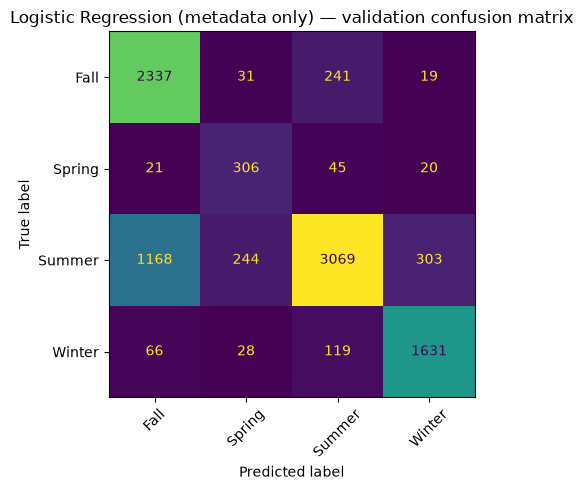

Saved metadata-only baseline to ../data/processed/task2_models


In [52]:
# Metadata-only baseline: how far do tabular features alone get us on season prediction,
# before we spend effort on the image branch at all?
BASELINE_DIR = OUT_DIR / 'task2_models'
BASELINE_DIR.mkdir(parents=True, exist_ok=True)

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
logreg.fit(meta_train, y_train)

logreg_train_f1 = f1_score(y_train, logreg.predict(meta_train), average='macro')
logreg_val_pred = logreg.predict(meta_val)
logreg_val_f1 = f1_score(y_val, logreg_val_pred, average='macro')

print(f'Logistic Regression (metadata only) -- train F1: {logreg_train_f1:.4f}, val F1: {logreg_val_f1:.4f}\n')
print(classification_report(y_val, logreg_val_pred, target_names=season_encoder.classes_))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, logreg_val_pred, display_labels=season_encoder.classes_,
    ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('Logistic Regression (metadata only) — validation confusion matrix')
plt.tight_layout()
plt.show()

joblib.dump(logreg, BASELINE_DIR / 'logreg_metadata_baseline.joblib')
print(f'Saved metadata-only baseline to {BASELINE_DIR}')

#### 1a. Ablation: does `productDisplayName` or `year` affect metadata-only prediction?

The baseline here includes every metadata field available, including `year` and a TF-IDF representation of the free-text `productDisplayName` field. From that full baseline, we remove `year`, then `productDisplayName`, then both together, to isolate what each one is actually contributing to `season` prediction. Random Forest is used here instead of Logistic Regression, since it handles the mixed one-hot/TF-IDF/numeric feature space without needing feature scaling, and can pick up non-linear interactions between fields that a linear model can't.

In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier

def build_metadata_matrix(train_df, val_df, use_year=True, use_text=False, text_max_features=300):
    """Rebuild the metadata design matrix with year and/or productDisplayName toggled on/off,
    reusing the same imputation/encoding strategy as the main meta_preprocessor above."""
    cat_features = list(META_CAT)  # gender, masterCategory, subCategory, articleType, baseColour, usage
    num_features = ['year'] if use_year else []
    text_col = ['productDisplayName'] if use_text else []

    transformers = [
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features)
    ]
    if num_features:
        transformers.append((
            'num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scale', StandardScaler())
            ]), num_features
        ))
    if use_text:
        # 'productDisplayName' as a bare string (not a list) makes ColumnTransformer pass a
        # 1D array to TfidfVectorizer, which is what it expects.
        transformers.append(('text', TfidfVectorizer(max_features=text_max_features, stop_words='english'),
                              'productDisplayName'))

    preprocessor = ColumnTransformer(transformers)

    cols = cat_features + num_features + text_col
    Xtr = train_df[cols].copy()
    Xva = val_df[cols].copy()
    for col in cat_features:
        Xtr[col] = Xtr[col].astype(object).where(Xtr[col].notna(), np.nan)
        Xva[col] = Xva[col].astype(object).where(Xva[col].notna(), np.nan)
    for col in num_features:
        Xtr[col] = pd.to_numeric(Xtr[col], errors='coerce')
        Xva[col] = pd.to_numeric(Xva[col], errors='coerce')
    for col in text_col:
        Xtr[col] = Xtr[col].astype(object).fillna('Unknown')
        Xva[col] = Xva[col].astype(object).fillna('Unknown')

    Mtr = preprocessor.fit_transform(Xtr).astype('float32')
    Mva = preprocessor.transform(Xva).astype('float32')
    return Mtr, Mva


def run_rf_ablation(name, train_matrix, val_matrix):
    model = RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    )
    model.fit(train_matrix, y_train)
    train_f1 = f1_score(y_train, model.predict(train_matrix), average='macro')
    val_f1 = f1_score(y_val, model.predict(val_matrix), average='macro')
    print(f'{name:42s} train F1: {train_f1:.4f}  val F1: {val_f1:.4f}')
    return train_f1, val_f1


ablation_results = {}

m_tr, m_va = build_metadata_matrix(task2_train, task2_val, use_year=True, use_text=True)
ablation_results['Baseline'] = run_rf_ablation('Baseline', m_tr, m_va)

m_tr, m_va = build_metadata_matrix(task2_train, task2_val, use_year=False, use_text=True)
ablation_results['Without year'] = run_rf_ablation('Without year', m_tr, m_va)

m_tr, m_va = build_metadata_matrix(task2_train, task2_val, use_year=True, use_text=False)
ablation_results['Without productDisplayName'] = run_rf_ablation('Without productDisplayName', m_tr, m_va)

m_tr, m_va = build_metadata_matrix(task2_train, task2_val, use_year=False, use_text=False)
ablation_results['Without year, without productDisplayName'] = run_rf_ablation(
    'Without year, without productDisplayName', m_tr, m_va)

ablation_df = pd.DataFrame(ablation_results, index=['Train F1', 'Validation F1']).T
display(ablation_df.round(4))


Baseline                                   train F1: 0.9601  val F1: 0.8698
Without year                               train F1: 0.8795  val F1: 0.7630
Without productDisplayName                 train F1: 0.8198  val F1: 0.7849
Without year, without productDisplayName   train F1: 0.6221  val F1: 0.5807


,Train F1,Validation F1
Baseline,0.9601,0.8698
Without year,0.8795,0.7630
Without productDisplayName,0.8198,0.7849
"Without year, without productDisplayName",0.6221,0.5807


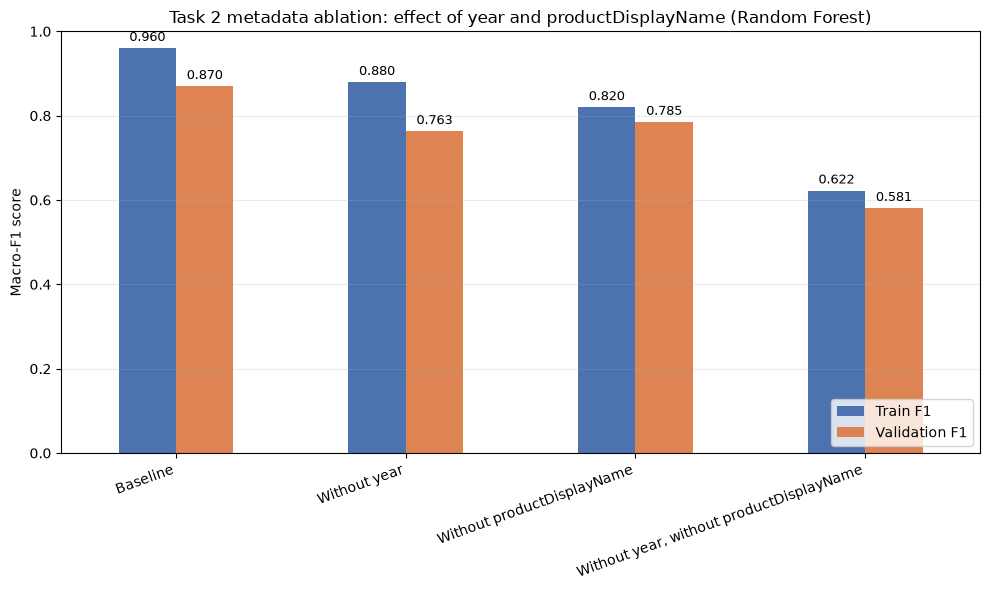

In [54]:
ax = ablation_df.plot(kind='bar', figsize=(10, 6), ylim=(0, 1), rot=20, color=['#4C72B0', '#DD8452'])
plt.ylabel('Macro-F1 score')
plt.title('Task 2 metadata ablation: effect of year and productDisplayName (Random Forest)')
plt.grid(axis='y', alpha=.25)
plt.xticks(ha='right')
plt.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout(); plt.show()


In [55]:
import copy
from torch import nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from torchvision.models import resnet18, ResNet18_Weights, mobilenet_v3_small, MobileNet_V3_Small_Weights, efficientnet_b0
from sklearn.preprocessing import StandardScaler

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE, EPOCHS, NUM_WORKERS = 128, 70, 6

sampler = get_weighted_sampler(task2_train, 'season')

class EarlyStopping:
    """Stops training when a monitored score stops improving.
    mode='max' for metrics like macro-F1 (higher is better).
    mode='min' for metrics like validation loss (lower is better)."""
    def __init__(self, patience=5, delta=0, mode='max'):
        assert mode in ('max', 'min')
        self.patience = patience
        self.delta = delta
        self.mode = mode
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_state = None

    def __call__(self, value, model):
        score = value if self.mode == 'max' else -value
        if self.best_score is None or score > self.best_score + self.delta:
            self.best_score = score
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def load_best_model(self, model):
        model.load_state_dict(self.best_state)
        return model

class MultiInputDataset(Dataset):
    def __init__(self, frame, metadata, labels, image_dir, transform):
        self.frame, self.metadata, self.labels = frame.reset_index(drop=True), metadata, labels
        self.image_dir, self.transform = image_dir, transform
    def __len__(self): return len(self.frame)
    def __getitem__(self, i):
        with Image.open(self.image_dir / f"{self.frame.iloc[i]['id']}.jpg") as im:
            image = self.transform(im)
        return image, torch.tensor(self.metadata[i].toarray() if hasattr(self.metadata[i], 'toarray') else self.metadata[i], dtype=torch.float32).squeeze(0), torch.tensor(self.labels[i], dtype=torch.long)

# Build datasets and loaders for the multi-input model.
train_ds = MultiInputDataset(task2_train, meta_train, y_train, IMAGES_TRAIN_DIR, train_transform)
val_ds = MultiInputDataset(task2_val, meta_val, y_val, IMAGES_TRAIN_DIR, eval_transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS,
                           persistent_workers=(NUM_WORKERS > 0))
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                         persistent_workers=(NUM_WORKERS > 0))

# Shared loaders for the two image-only comparison models (built once, reused for both
# ResNet18 and MobileNetV3 so workers aren't spun up and torn down twice).
train_ds_img = FashionImageDataset(task2_train, IMAGES_TRAIN_DIR, 'season_enc', train_transform)
train_loader_img = DataLoader(train_ds_img, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS,
                            persistent_workers=(NUM_WORKERS > 0))
val_loader_img = DataLoader(FashionImageDataset(task2_val, IMAGES_TRAIN_DIR, 'season_enc', eval_transform),
                            batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
                            persistent_workers=(NUM_WORKERS > 0))

# Create pretrained image-only comparison models and replace their classifiers for season prediction.
def make_pretrained(model_name):
    if model_name == 'resnet18':
        model = resnet18(weights=ResNet18_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, len(season_encoder.classes_))
    else:
        model = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, len(season_encoder.classes_))
    return model.to(DEVICE)

class PretrainedResNet18Encoder(nn.Module):
    """ImageNet-pretrained ResNet18 as a feature extractor for MultiInputNet --
    the missing cell of the 2x2 grid: pretrained encoder WITH metadata."""
    def __init__(self, out_dim=128):
        super().__init__()
        backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.out_dim = out_dim
        self.proj = nn.Linear(512, out_dim)

    def forward(self, x):
        return self.proj(self.backbone(x))

class SmallImageEncoder(nn.Module):
    """From-scratch CNN sized for 60x80 images — no aggressive early downsampling."""
    def __init__(self, out_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),                                    # 60x80 -> 30x40

            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),                                    # 30x40 -> 15x20

            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.out_dim = out_dim
        self.proj = nn.Linear(128, out_dim)

    def forward(self, x):
        return self.proj(self.features(x).flatten(1))

class ResNet18Encoder(nn.Module):
    """From-scratch ResNet18 backbone, weights=None — kept as a comparison point
    against SmallImageEncoder to show whether stem downsampling hurts at 60x80."""
    def __init__(self, out_dim=128):
        super().__init__()
        backbone = resnet18(weights=None)
        self.out_dim = out_dim
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.proj = nn.Linear(512, out_dim)

    def forward(self, x):
        return self.proj(self.backbone(x))

class EfficientNetEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        backbone = efficientnet_b0(weights=None)

        self.out_dim = out_dim
        # Replace classifier with Identity to get raw backbone features (1280-dim)
        backbone.classifier = nn.Identity()
        self.backbone = backbone
        
        # Project directly from 1280 features to out_dim (128)
        self.proj = nn.Linear(1280, out_dim)
    def forward(self, x):
        return self.proj(self.backbone(x))

class ConvBlock(nn.Module):
    """Residual Conv Block with SiLU and BatchNorm."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.act = nn.SiLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # Shortcut matching if channels change
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.act(out + residual)


class ImprovedSmallImageEncoder(nn.Module):
    """Upgraded small CNN with residual connections, SiLU activations, 
    and gradual spatial downsampling for 60x80 images."""
    def __init__(self, out_dim=128, dropout=0.2):
        super().__init__()
        self.out_dim = out_dim
        
        self.stage1 = ConvBlock(3, 32)
        self.pool1  = nn.MaxPool2d(2)                            # 60x80 -> 30x40
        
        self.stage2 = ConvBlock(32, 64)
        self.pool2  = nn.MaxPool2d(2)                            # 30x40 -> 15x20
        
        self.stage3 = ConvBlock(64, 128)
        self.pool3  = nn.MaxPool2d(2)                            # 15x20 -> 7x10
        
        self.stage4 = ConvBlock(128, 256)
        self.global_pool = nn.AdaptiveAvgPool2d(1)               # 7x10  -> 1x1
        
        self.proj = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(256, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.SiLU()
        )

    def forward(self, x):
        x = self.pool1(self.stage1(x))
        x = self.pool2(self.stage2(x))
        x = self.pool3(self.stage3(x))
        x = self.stage4(x)
        
        x = self.global_pool(x).flatten(1)
        return self.proj(x)

class MultiInputNet(nn.Module):
    def __init__(self, metadata_dim, n_classes, image_encoder):
        super().__init__()
        self.image = image_encoder
        image_dim = image_encoder.out_dim
        self.meta_scale = nn.Parameter(torch.tensor(1.0))
        self.meta = nn.Sequential(
            nn.BatchNorm1d(metadata_dim),
            nn.Linear(metadata_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.head = nn.Sequential(
            nn.Linear(image_dim + 128, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes)
        )
        
    def forward(self, image, metadata):
        img_feats = self.image(image)
        meta_feats = self.meta(metadata) * self.meta_scale
        fused = torch.cat([img_feats, meta_feats], dim=1)
        return self.head(fused)

In [56]:
def plot_training_curves(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    axes[0].plot(history['train_loss'], label='Train loss')
    axes[0].plot(history['val_loss'], label='Val loss')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

    axes[1].plot(history['train_f1'], label='Train macro-F1')
    axes[1].plot(history['val_f1'], label='Val macro-F1')
    axes[1].set_title('Macro-F1'); axes[1].set_xlabel('Epoch'); axes[1].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


def to_device(batch):
    """Both loaders end with the label; everything before it is model input.
    (image, label) -> inputs=[image]. (image, metadata, label) -> inputs=[image, metadata].
    This one line is what lets train_model and train_image_only collapse into one function."""
    *inputs, labels = batch
    return [x.to(DEVICE) for x in inputs], labels.to(DEVICE)


def run_epoch(model, loader, criterion, optimiser=None, desc=''):
    """One pass over `loader`. Training if `optimiser` is given, eval-only otherwise."""
    train_mode = optimiser is not None
    model.train() if train_mode else model.eval()

    running_loss, n, preds, actual = 0.0, 0, [], []
    with torch.set_grad_enabled(train_mode):
        for batch in tqdm(loader, desc=desc, leave=train_mode):
            inputs, labels = to_device(batch)
            logits = model(*inputs)
            loss = criterion(logits, labels)

            if train_mode:
                optimiser.zero_grad()
                loss.backward()
                optimiser.step()

            bs = labels.size(0)
            running_loss += loss.item() * bs
            n += bs
            preds.extend(logits.argmax(1).detach().cpu().numpy())
            actual.extend(labels.cpu().numpy())

    return running_loss / n, f1_score(actual, preds, average='macro')


def fit(model, loader_tr, loader_va, model_name='model', patience=15, lr=3e-4, weight_decay=1e-4):
    """Replaces train_model and train_image_only. Same optimiser settings for every
    model (train_image_only used to skip weight_decay -- that was an accident of
    copy-paste, not a deliberate choice, so it's gone now)."""
    criterion = nn.CrossEntropyLoss()
    optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=2)
    early_stopping = EarlyStopping(patience=patience, delta=0.0, mode='min')
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_val_f1 = None
    best_val_loss = None
    best_epoch = None

    for epoch in range(EPOCHS):
        tag = f'{model_name} {epoch + 1}/{EPOCHS}'
        train_loss, train_f1 = run_epoch(model, loader_tr, criterion, optimiser, desc=f'{tag} train')
        val_loss, val_f1 = run_epoch(model, loader_va, criterion, None, desc=f'{tag} val')

        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
        history['train_f1'].append(train_f1); history['val_f1'].append(val_f1)
        current_lr = optimiser.param_groups[0]['lr']
        print(f'Epoch {epoch + 1}/{EPOCHS} - train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f} - '
              f'train_f1: {train_f1:.4f} - val_f1: {val_f1:.4f} - lr: {current_lr:.2e}')

        scheduler.step(val_loss)
        early_stopping(val_loss, model)
        if early_stopping.counter == 0:
            best_val_f1 = val_f1
            best_val_loss = val_loss
            best_epoch = epoch + 1
        if early_stopping.early_stop:
            print(f'Early stopping triggered at epoch {epoch + 1} (best epoch was {best_epoch})')
            break

    model = early_stopping.load_best_model(model)
    plot_training_curves(history, model_name)

    print(f'>>> Best checkpoint for {model_name}: epoch {best_epoch}  '
          f'(val_loss={best_val_loss:.4f}, val_f1={best_val_f1:.4f})')

    return model, best_val_f1, best_epoch


def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_actual = []
    
    with torch.no_grad():
        for batch in loader:
            inputs, labels = to_device(batch)
            
            # Keep predictions and labels on GPU as tensors
            preds = model(*inputs).argmax(dim=1)
            
            all_preds.append(preds)
            all_actual.append(labels)
            
    # Concatenate directly on GPU, then transfer to CPU ONCE
    preds_np = torch.cat(all_preds).cpu().numpy()
    actual_np = torch.cat(all_actual).cpu().numpy()
    
    return f1_score(actual_np, preds_np, average='macro')


ResNet18 (pretrained) 1/70 train:   0%|          | 0/227 [00:00<?, ?it/s]

ResNet18 (pretrained) 1/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.8180 - val_loss: 0.8195 - train_f1: 0.6484 - val_f1: 0.6036 - lr: 3.00e-04


ResNet18 (pretrained) 2/70 train:   0%|          | 0/227 [00:00<?, ?it/s]

ResNet18 (pretrained) 2/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

...

ResNet18 (pretrained) 24/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 24/70 - train_loss: 0.0638 - val_loss: 1.0366 - train_f1: 0.9768 - val_f1: 0.7688 - lr: 1.87e-05


ResNet18 (pretrained) 25/70 train:   0%|          | 0/227 [00:00<?, ?it/s]

ResNet18 (pretrained) 25/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 25/70 - train_loss: 0.0622 - val_loss: 1.0601 - train_f1: 0.9784 - val_f1: 0.7721 - lr: 1.87e-05
Early stopping triggered at epoch 25 (best epoch was 10)


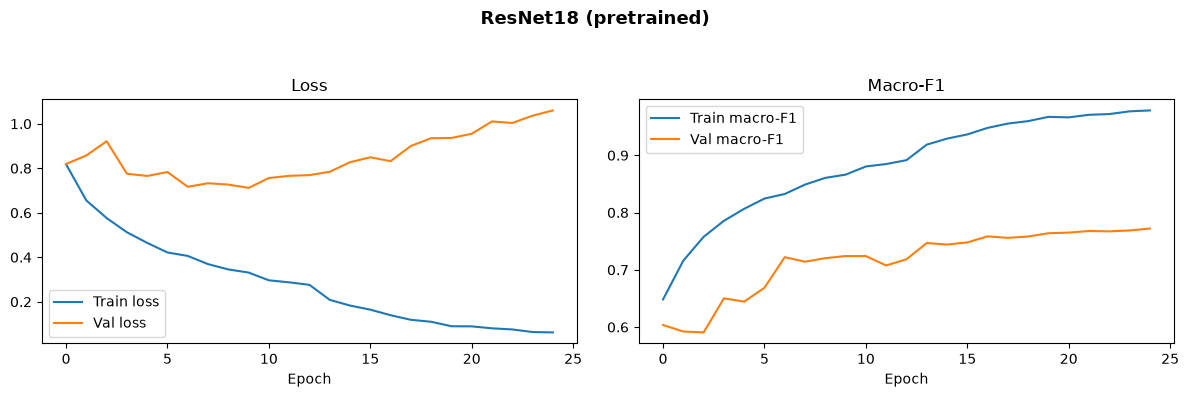

>>> Best checkpoint for ResNet18 (pretrained): epoch 10  (val_loss=0.7119, val_f1=0.7241)


In [57]:
OUTPUT_DIR = Path('../outputs') / 'task2_models'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
torch.manual_seed(RANDOM_STATE)
results = {}
resnet_model, resnet_f1, resnet_epoch = fit(
    make_pretrained('resnet18'), train_loader_img, val_loader_img, model_name='ResNet18 (pretrained)')
results['ResNet18 (pretrained)'] = (resnet_f1, resnet_epoch)

ResNet18 (pretrained, image only) -- train F1: 0.8608, val F1: 0.7241

              precision    recall  f1-score   support

        Fall       0.65      0.69      0.67      2628
      Spring       0.71      0.72      0.72       392
      Summer       0.78      0.73      0.76      4784
      Winter       0.73      0.79      0.76      1844

    accuracy                           0.73      9648
   macro avg       0.72      0.73      0.72      9648
weighted avg       0.73      0.73      0.73      9648



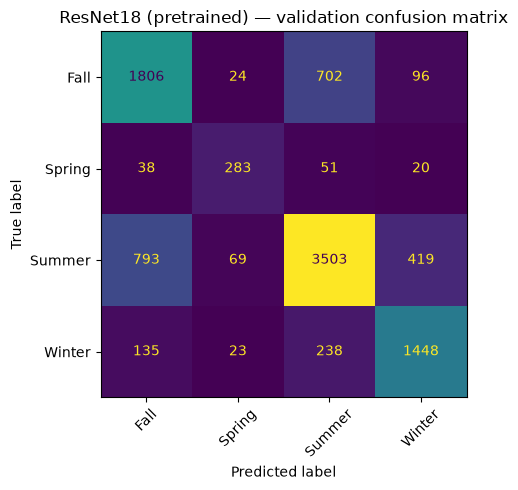

In [58]:
# Testing: ResNet18 (pretrained, image-only) -- same treatment as the metadata-only
# baseline above (val F1, classification report, confusion matrix), so both baselines
# are fully tested here before we move on to the multi-input models.
image_train_loader = DataLoader(
    FashionImageDataset(task2_train, IMAGES_TRAIN_DIR, 'season_enc', eval_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)
image_val_loader = DataLoader(
    FashionImageDataset(task2_val, IMAGES_TRAIN_DIR, 'season_enc', eval_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)

resnet_train_f1 = evaluate(resnet_model, image_train_loader)

resnet_model.eval()
resnet_val_preds = []
with torch.no_grad():
    for images, labels in image_val_loader:
        images = images.to(DEVICE)
        preds = resnet_model(images).argmax(dim=1).cpu().numpy()
        resnet_val_preds.extend(preds)
resnet_val_preds = np.array(resnet_val_preds)
resnet_val_f1 = f1_score(y_val, resnet_val_preds, average='macro')

print(f'ResNet18 (pretrained, image only) -- train F1: {resnet_train_f1:.4f}, val F1: {resnet_val_f1:.4f}\n')
print(classification_report(y_val, resnet_val_preds, target_names=season_encoder.classes_))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, resnet_val_preds, display_labels=season_encoder.classes_,
    ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('ResNet18 (pretrained) — validation confusion matrix')
plt.tight_layout()
plt.show()


#### 1c. ImprovedSmallCNN (image-only)

`styles_prediction.csv` (the real test set) has no metadata at all, so the multi-input model can't run on it directly -- `MultiInputNet` requires both an image and a metadata vector. This image-only version of our chosen encoder (`ImprovedSmallImageEncoder`) is what we actually use for test-set predictions. It's trained and tested here, alongside the other image-only/metadata-only baselines, before the multi-input section.

ImprovedSmallCNN (image-only) 1/70 train:   0%|          | 0/227 [00:00<?, ?it/s]

ImprovedSmallCNN (image-only) 1/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.9986 - val_loss: 1.0583 - train_f1: 0.5453 - val_f1: 0.5415 - lr: 3.00e-04


ImprovedSmallCNN (image-only) 2/70 train:   0%|          | 0/227 [00:00<?, ?it/s]

ImprovedSmallCNN (image-only) 2/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

...

ImprovedSmallCNN (image-only) 36/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 36/70 - train_loss: 0.3442 - val_loss: 0.6976 - train_f1: 0.8618 - val_f1: 0.7181 - lr: 1.17e-06


ImprovedSmallCNN (image-only) 37/70 train:   0%|          | 0/227 [00:00<?, ?it/s]

ImprovedSmallCNN (image-only) 37/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 37/70 - train_loss: 0.3405 - val_loss: 0.6977 - train_f1: 0.8607 - val_f1: 0.7214 - lr: 1.17e-06
Early stopping triggered at epoch 37 (best epoch was 22)


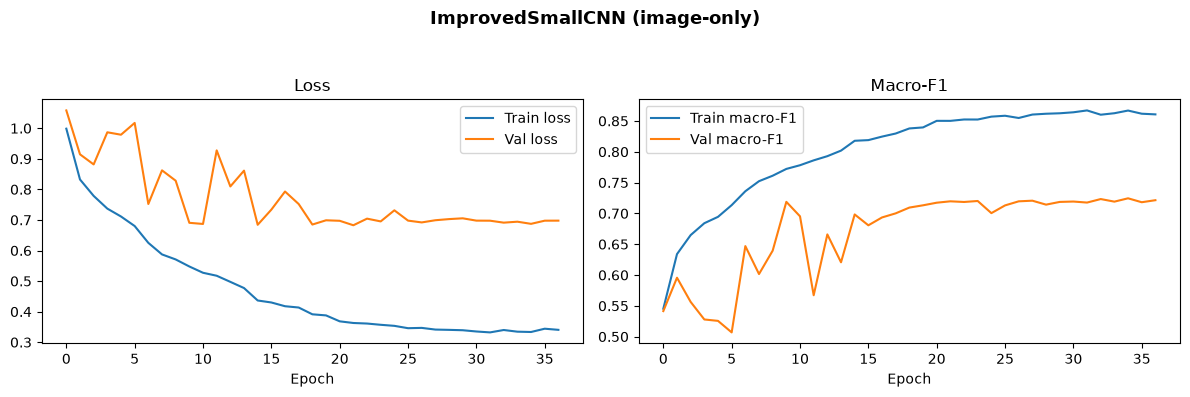

>>> Best checkpoint for ImprovedSmallCNN (image-only): epoch 22  (val_loss=0.6826, val_f1=0.7196)


In [59]:
class ImageOnlyClassifier(nn.Module):
    """An encoder plus a plain linear head -- no metadata branch. Used to get a
    working model for images with no metadata, e.g. the real test set."""
    def __init__(self, encoder, n_classes):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Linear(encoder.out_dim, n_classes)

    def forward(self, x):
        return self.head(self.encoder(x))


torch.manual_seed(RANDOM_STATE)
improved_small_cnn_img_only_model, improved_small_cnn_img_only_f1, improved_small_cnn_img_only_epoch = fit(
    ImageOnlyClassifier(ImprovedSmallImageEncoder(out_dim=128), len(season_encoder.classes_)).to(DEVICE),
    train_loader_img, val_loader_img, model_name='ImprovedSmallCNN (image-only)')
results['ImprovedSmallCNN (image-only)'] = (improved_small_cnn_img_only_f1, improved_small_cnn_img_only_epoch)


ImprovedSmallCNN (image only) -- train F1: 0.8426, val F1: 0.7196

              precision    recall  f1-score   support

        Fall       0.69      0.71      0.70      2628
      Spring       0.67      0.72      0.70       392
      Summer       0.80      0.72      0.76      4784
      Winter       0.67      0.79      0.73      1844

    accuracy                           0.73      9648
   macro avg       0.71      0.74      0.72      9648
weighted avg       0.74      0.73      0.73      9648



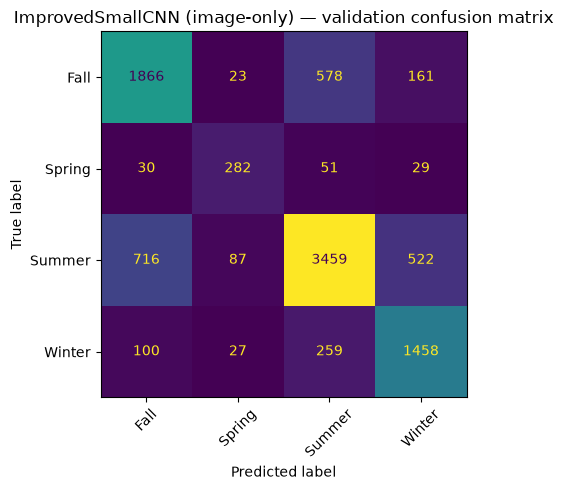

Saved ImprovedSmallCNN (image-only) to ../outputs/task2_models/improved_small_cnn_image_only.pt


In [60]:
# Testing: ImprovedSmallCNN (image-only) -- same treatment as the other baselines above.
improved_small_cnn_img_only_train_f1 = evaluate(improved_small_cnn_img_only_model, image_train_loader)

improved_small_cnn_img_only_model.eval()
improved_img_only_val_preds = []
with torch.no_grad():
    for images, labels in image_val_loader:
        images = images.to(DEVICE)
        preds = improved_small_cnn_img_only_model(images).argmax(dim=1).cpu().numpy()
        improved_img_only_val_preds.extend(preds)
improved_img_only_val_preds = np.array(improved_img_only_val_preds)
improved_small_cnn_img_only_val_f1 = f1_score(y_val, improved_img_only_val_preds, average='macro')

print(f'ImprovedSmallCNN (image only) -- train F1: {improved_small_cnn_img_only_train_f1:.4f}, '
      f'val F1: {improved_small_cnn_img_only_val_f1:.4f}\n')
print(classification_report(y_val, improved_img_only_val_preds, target_names=season_encoder.classes_))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, improved_img_only_val_preds, display_labels=season_encoder.classes_,
    ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('ImprovedSmallCNN (image-only) — validation confusion matrix')
plt.tight_layout()
plt.show()

# Saved separately since this (not the multi-input model) is what's actually used for
# the metadata-free test set.
torch.save({
    'model_state_dict': improved_small_cnn_img_only_model.state_dict(),
    'n_classes': len(season_encoder.classes_),
    'out_dim': 128,
    'val_f1': improved_small_cnn_img_only_val_f1,
}, OUTPUT_DIR / 'improved_small_cnn_image_only.pt')
print(f'Saved ImprovedSmallCNN (image-only) to {OUTPUT_DIR / "improved_small_cnn_image_only.pt"}')


#### 2. Multi-input model training

MultiInput-ResNet18Pretrained 1/70 train:   0%|          | 0/227 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained 1/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.7713 - val_loss: 0.6994 - train_f1: 0.6650 - val_f1: 0.7076 - lr: 3.00e-04


MultiInput-ResNet18Pretrained 2/70 train:   0%|          | 0/227 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained 2/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

...

MultiInput-ResNet18Pretrained 27/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 27/70 - train_loss: 0.0468 - val_loss: 0.7761 - train_f1: 0.9838 - val_f1: 0.8337 - lr: 9.37e-06


MultiInput-ResNet18Pretrained 28/70 train:   0%|          | 0/227 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained 28/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 28/70 - train_loss: 0.0466 - val_loss: 0.7680 - train_f1: 0.9839 - val_f1: 0.8350 - lr: 9.37e-06
Early stopping triggered at epoch 28 (best epoch was 13)


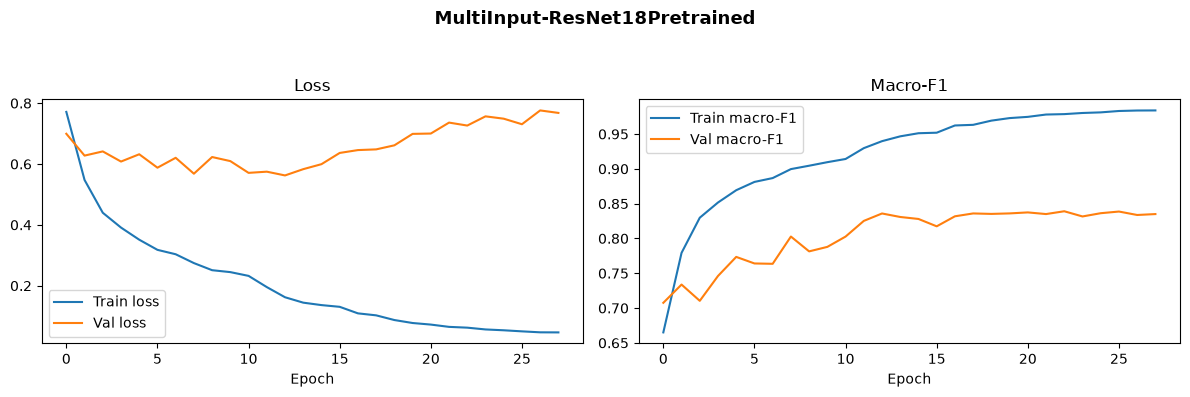

>>> Best checkpoint for MultiInput-ResNet18Pretrained: epoch 13  (val_loss=0.5625, val_f1=0.8359)


In [61]:
torch.manual_seed(RANDOM_STATE)
resnet_pretrained_model, resnet_pretrained_f1, resnet_pretrained_epoch = fit(
    MultiInputNet(meta_train.shape[1], len(season_encoder.classes_), PretrainedResNet18Encoder(out_dim=128)).to(DEVICE),
    train_loader, val_loader, model_name='MultiInput-ResNet18Pretrained')
results['MultiInput-ResNet18Pretrained'] = (resnet_pretrained_f1, resnet_pretrained_epoch)


MultiInput-SmallCNN 1/70 train:   0%|          | 0/227 [00:00<?, ?it/s]

MultiInput-SmallCNN 1/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.8794 - val_loss: 0.8356 - train_f1: 0.6140 - val_f1: 0.6307 - lr: 3.00e-04


MultiInput-SmallCNN 2/70 train:   0%|          | 0/227 [00:00<?, ?it/s]

MultiInput-SmallCNN 2/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

...

MultiInput-SmallCNN 48/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 48/70 - train_loss: 0.3316 - val_loss: 0.5617 - train_f1: 0.8826 - val_f1: 0.7894 - lr: 1.17e-06


MultiInput-SmallCNN 49/70 train:   0%|          | 0/227 [00:00<?, ?it/s]

MultiInput-SmallCNN 49/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 49/70 - train_loss: 0.3261 - val_loss: 0.5524 - train_f1: 0.8848 - val_f1: 0.7868 - lr: 1.17e-06
Early stopping triggered at epoch 49 (best epoch was 34)


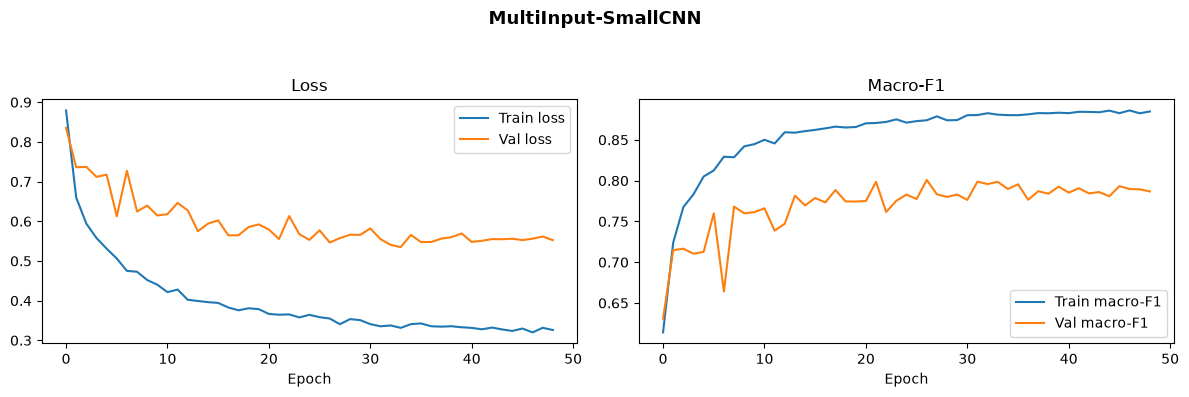

>>> Best checkpoint for MultiInput-SmallCNN: epoch 34  (val_loss=0.5349, val_f1=0.7986)


In [62]:
torch.manual_seed(RANDOM_STATE)
small_cnn_model, small_cnn_f1, small_cnn_epoch = fit(
    MultiInputNet(meta_train.shape[1], len(season_encoder.classes_), SmallImageEncoder(out_dim=128)).to(DEVICE), train_loader, val_loader,
    model_name='MultiInput-SmallCNN')
results['MultiInput-SmallCNN'] = (small_cnn_f1, small_cnn_epoch)

MultiInput-ResNet18Scratch 1/70 train:   0%|          | 0/227 [00:00<?, ?it/s]

MultiInput-ResNet18Scratch 1/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.8400 - val_loss: 0.7520 - train_f1: 0.6252 - val_f1: 0.6852 - lr: 3.00e-04


MultiInput-ResNet18Scratch 2/70 train:   0%|          | 0/227 [00:00<?, ?it/s]

MultiInput-ResNet18Scratch 2/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

...

MultiInput-ResNet18Scratch 29/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 29/70 - train_loss: 0.1122 - val_loss: 0.6627 - train_f1: 0.9597 - val_f1: 0.8281 - lr: 1.87e-05


MultiInput-ResNet18Scratch 30/70 train:   0%|          | 0/227 [00:00<?, ?it/s]

MultiInput-ResNet18Scratch 30/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 30/70 - train_loss: 0.1112 - val_loss: 0.6639 - train_f1: 0.9596 - val_f1: 0.8267 - lr: 1.87e-05
Early stopping triggered at epoch 30 (best epoch was 15)


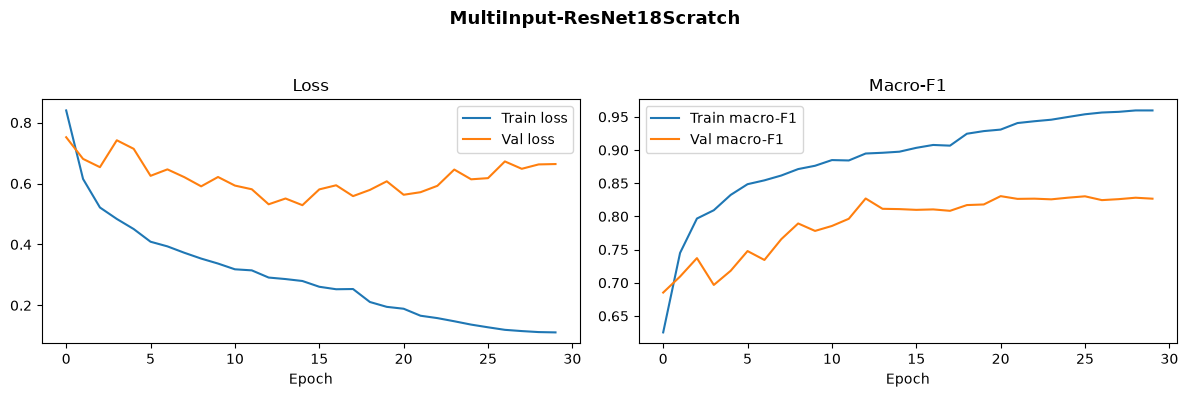

>>> Best checkpoint for MultiInput-ResNet18Scratch: epoch 15  (val_loss=0.5289, val_f1=0.8110)


In [63]:
torch.manual_seed(RANDOM_STATE)
resnet_scratch_model, resnet_scratch_f1, resnet_scratch_epoch = fit(
    MultiInputNet(meta_train.shape[1], len(season_encoder.classes_), ResNet18Encoder(out_dim=128)).to(DEVICE), train_loader, val_loader,
    model_name='MultiInput-ResNet18Scratch')
results['MultiInput-ResNet18Scratch'] = (resnet_scratch_f1, resnet_scratch_epoch)

MultiInput-EfficientNet 1/70 train:   0%|          | 0/227 [00:00<?, ?it/s]

MultiInput-EfficientNet 1/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.8934 - val_loss: 0.8156 - train_f1: 0.6207 - val_f1: 0.6045 - lr: 3.00e-04


MultiInput-EfficientNet 2/70 train:   0%|          | 0/227 [00:00<?, ?it/s]

MultiInput-EfficientNet 2/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

...

MultiInput-EfficientNet 35/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 35/70 - train_loss: 0.2664 - val_loss: 0.5712 - train_f1: 0.9044 - val_f1: 0.8220 - lr: 4.69e-06


MultiInput-EfficientNet 36/70 train:   0%|          | 0/227 [00:00<?, ?it/s]

MultiInput-EfficientNet 36/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 36/70 - train_loss: 0.2680 - val_loss: 0.5350 - train_f1: 0.9042 - val_f1: 0.8281 - lr: 4.69e-06
Early stopping triggered at epoch 36 (best epoch was 21)


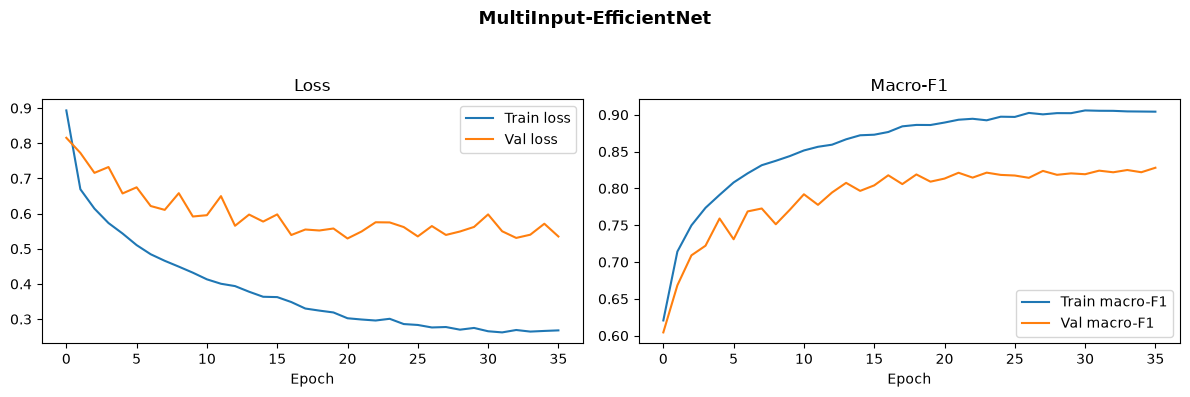

>>> Best checkpoint for MultiInput-EfficientNet: epoch 21  (val_loss=0.5293, val_f1=0.8134)


In [64]:
torch.manual_seed(RANDOM_STATE)
efficientNet_scratch_model, efficientNet_scratch_f1, efficientNet_scratch_epoch = fit(
    MultiInputNet(meta_train.shape[1], len(season_encoder.classes_), EfficientNetEncoder(out_dim=128)).to(DEVICE), train_loader, val_loader,
    model_name='MultiInput-EfficientNet')
results['MultiInput-EfficientNet'] = (efficientNet_scratch_f1, efficientNet_scratch_epoch)

MultiInput-ImprovedSmallCNN 1/70 train:   0%|          | 0/227 [00:00<?, ?it/s]

MultiInput-ImprovedSmallCNN 1/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.8717 - val_loss: 0.7814 - train_f1: 0.6210 - val_f1: 0.6526 - lr: 3.00e-04


MultiInput-ImprovedSmallCNN 2/70 train:   0%|          | 0/227 [00:00<?, ?it/s]

MultiInput-ImprovedSmallCNN 2/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

...

MultiInput-ImprovedSmallCNN 47/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 47/70 - train_loss: 0.2156 - val_loss: 0.5407 - train_f1: 0.9209 - val_f1: 0.8309 - lr: 2.93e-07


MultiInput-ImprovedSmallCNN 48/70 train:   0%|          | 0/227 [00:00<?, ?it/s]

MultiInput-ImprovedSmallCNN 48/70 val:   0%|          | 0/76 [00:00<?, ?it/s]

Epoch 48/70 - train_loss: 0.2119 - val_loss: 0.5497 - train_f1: 0.9207 - val_f1: 0.8287 - lr: 2.93e-07
Early stopping triggered at epoch 48 (best epoch was 33)


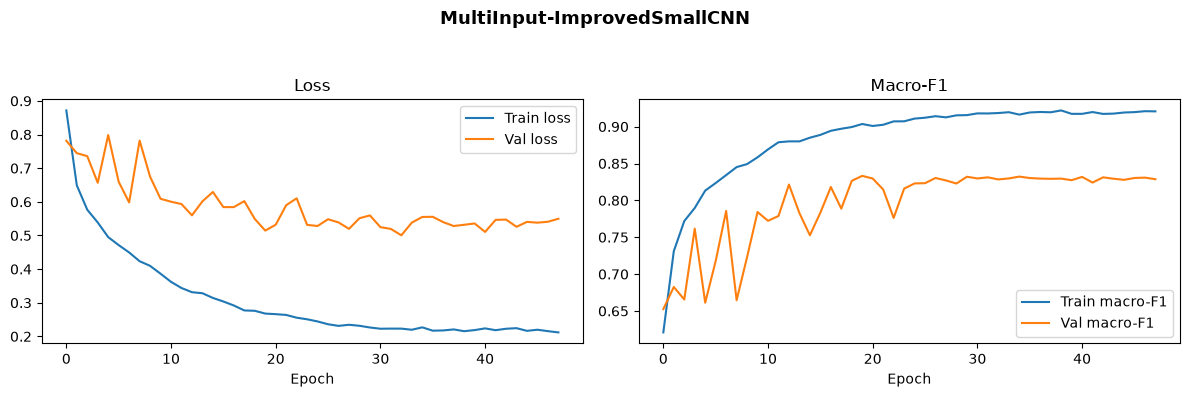

>>> Best checkpoint for MultiInput-ImprovedSmallCNN: epoch 33  (val_loss=0.5005, val_f1=0.8284)


In [65]:
torch.manual_seed(RANDOM_STATE)

improved_small_cnn_model, improved_small_cnn_f1, improved_small_cnn_epoch = fit(
    MultiInputNet(
        metadata_dim=meta_train.shape[1], 
        n_classes=len(season_encoder.classes_), 
        image_encoder=ImprovedSmallImageEncoder(out_dim=128)
    ).to(DEVICE), 
    train_loader, 
    val_loader,
    model_name='MultiInput-ImprovedSmallCNN'
)

results['MultiInput-ImprovedSmallCNN'] = (improved_small_cnn_f1, improved_small_cnn_epoch)

In [66]:
PRETRAINED_MODELS = {'ResNet18 (pretrained)', 'MobileNetV3-Small (pretrained)', 'MultiInput-ResNet18Pretrained'}
saveable_results = {k: v for k, v in results.items() if k not in PRETRAINED_MODELS}

best_name = max(saveable_results, key=lambda k: saveable_results[k][0])
best_f1, best_epoch_num = saveable_results[best_name]

print('=== Early-stopping checkpoint summary ===')
for name, (f1, epoch) in sorted(results.items(), key=lambda kv: -kv[1][0]):
    if name == best_name:
        marker = '  <-- best (saveable)'
    elif name in PRETRAINED_MODELS:
        marker = '  (pretrained -- excluded from saving)'
    else:
        marker = ''
    print(f'{name:35s}  val_f1={f1:.4f}  (best epoch: {epoch}){marker}')

print(f'\nBest performing SAVEABLE model: {best_name} (val_f1={best_f1:.4f} at epoch {best_epoch_num})')

=== Early-stopping checkpoint summary ===
MultiInput-ResNet18Pretrained        val_f1=0.8359  (best epoch: 13)  (pretrained -- excluded from saving)
MultiInput-ImprovedSmallCNN          val_f1=0.8284  (best epoch: 33)  <-- best (saveable)
MultiInput-EfficientNet              val_f1=0.8134  (best epoch: 21)
MultiInput-ResNet18Scratch           val_f1=0.8110  (best epoch: 15)
MultiInput-SmallCNN                  val_f1=0.7986  (best epoch: 34)
ResNet18 (pretrained)                val_f1=0.7241  (best epoch: 10)  (pretrained -- excluded from saving)
ImprovedSmallCNN (image-only)        val_f1=0.7196  (best epoch: 22)

Best performing SAVEABLE model: MultiInput-ImprovedSmallCNN (val_f1=0.8284 at epoch 33)


In [67]:
model_lookup = {
    'ResNet18 (pretrained)': resnet_model,
    'MultiInput-EfficientNet': efficientNet_scratch_model,
    'MultiInput-SmallCNN': small_cnn_model,
    'MultiInput-ResNet18Scratch': resnet_scratch_model,
    'MultiInput-ResNet18Pretrained': resnet_pretrained_model,
    'MultiInput-ImprovedSmallCNN': improved_small_cnn_model
}


In [68]:
# Evaluate both splits and compare all models
multi_train_loader = DataLoader(
    MultiInputDataset(task2_train, meta_train, y_train, IMAGES_TRAIN_DIR, eval_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

multi_val_loader = DataLoader(
    MultiInputDataset(task2_val, meta_val, y_val, IMAGES_TRAIN_DIR, eval_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

scores = pd.DataFrame({
    'Train F1': [
        logreg_train_f1,
        resnet_train_f1,
        improved_small_cnn_img_only_train_f1,
        evaluate(efficientNet_scratch_model, multi_train_loader),
        evaluate(small_cnn_model, multi_train_loader),
        evaluate(improved_small_cnn_model, multi_train_loader),
        evaluate(resnet_scratch_model, multi_train_loader),
        evaluate(resnet_pretrained_model, multi_train_loader),
    ],
    'Validation F1': [
        logreg_val_f1,
        resnet_val_f1,
        improved_small_cnn_img_only_val_f1,
        evaluate(efficientNet_scratch_model, multi_val_loader),
        evaluate(small_cnn_model, multi_val_loader),
        evaluate(improved_small_cnn_model, multi_val_loader),
        evaluate(resnet_scratch_model, multi_val_loader),
        evaluate(resnet_pretrained_model, multi_val_loader),
    ]
}, index=[
    'Logistic Regression', 
    'ResNet18 (pretrained)',
    'MultiInput-EfficientNet', 
    'MultiInput-SmallCNN', 
    'MultiInput-ImprovedSmallCNN',
    'MultiInput-ResNet18Scratch', 
    'MultiInput-ResNet18Pretrained',
])

display(scores.round(4))

,Train F1,Validation F1
Logistic Regression,0.7359,0.7402
ResNet18 (pretrained),0.8608,0.7241
MultiInput-EfficientNet,0.8610,0.8134
MultiInput-SmallCNN,0.8402,0.7986
MultiInput-ImprovedSmallCNN,0.9073,0.8284
MultiInput-ResNet18Scratch,0.8829,0.8110
MultiInput-ResNet18Pretrained,0.9434,0.8359


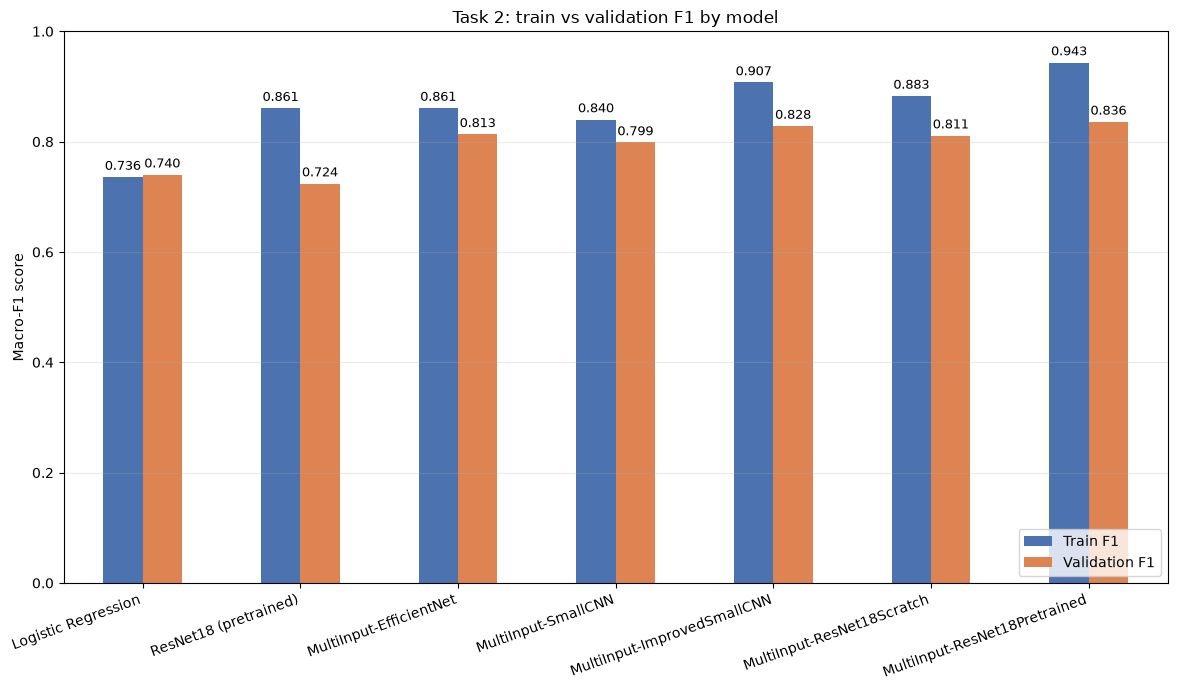

In [69]:
ax = scores.plot(kind='bar', figsize=(12, 7), ylim=(0, 1), rot=20, color=['#4C72B0', '#DD8452'])
plt.ylabel('Macro-F1 score'); plt.title('Task 2: train vs validation F1 by model'); plt.grid(axis='y', alpha=.25)
plt.xticks(ha='right')
plt.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout(); plt.show()